# Unified Dataset

## Classified statements

In [1]:
import pandas as pd
import json

file_path = r"C:\Users\spatt\Desktop\namingnames\classdeductive\run_01\results.jsonl"

# 1) Load the JSONL as-is (keeps all original columns)
df = pd.read_json(file_path, lines=True)

# 2) Parse year and classification from the "output" field and add as new columns
def parse_output(output_str):
    if not isinstance(output_str, str):
        return pd.Series([None, None])
    cleaned = output_str.replace("<analysis>", "").replace("</analysis>", "").strip()
    try:
        parsed = json.loads(cleaned)
        return pd.Series([parsed.get("year"), parsed.get("classification")])
    except json.JSONDecodeError:
        return pd.Series([None, None])

df[["year", "classification"]] = df["output"].apply(parse_output)

# Optional: make year integer dtype (nullable) and tidy classification text
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["classification"] = df["classification"].astype("string")

# 3) Now filter rows that have the required fields present
required = ["source", "target", "year", "classification", "item_id", "chunk_id", "doc_id"]
df = df.dropna(subset=required, how="any")

cols_to_drop = [
    "started_at",
    "finished_at",
    "output",
    "thinking",
    "analysis",
    "analysis_text"
]

df = df.drop(columns=cols_to_drop, errors="ignore")


print(df.head())
print(df.dtypes)


                item_id source target    chunk_id       doc_id  year  \
0  GBR__RUS__GBR_7_1946    GBR    RUS  GBR_7_1946  GBR_01_1946  1946   
1  GBR__GRC__GBR_7_1946    GBR    GRC  GBR_7_1946  GBR_01_1946  1946   
2  IND__ZAF__IND_3_1946    IND    ZAF  IND_3_1946  IND_01_1946  1946   
3  GBR__YUG__GBR_2_1946    GBR    YUG  GBR_2_1946  GBR_01_1946  1946   
4  BEL__ESP__BEL_2_1946    BEL    ESP  BEL_2_1946  BEL_01_1946  1946   

               classification  
0  global governance critique  
1  global governance critique  
2  global governance critique  
3  global governance critique  
4        foreign interference  
item_id                   object
source                    object
target                    object
chunk_id                  object
doc_id                    object
year                       Int64
classification    string[python]
dtype: object


## Graph Data

In [2]:
import json
import pandas as pd
from collections import Counter

# Load the JSON data
file_path = r"C:\Users\spatt\Desktop\namingnames\docanalysis\output\graph_data_20250809_060817.json"

with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Convert to DataFrame for easier analysis
graph = pd.DataFrame(data)

graph.head()


,source,target,year,rhetorical_move,full_text,tags
0,BEL,ESP,1946,Belgium accuses Spain of complicity with Axis ...,Belgium highlights Spain's role in aiding and ...,"[#complicity_with_axis_powers, #protection_of_..."
1,IND,ZAF,1946,India accuses South Africa of violating UN pri...,India brings attention to South Africa's treat...,"[#racial_discrimination, #victims:indians(raci..."
2,GBR,YUG,1946,GBR accuses Yugoslavia of failing to recognize...,GBR highlights Yugoslavia's lack of appreciati...,"[#UN_effectiveness, #UNRRA_success, #post-war_..."
3,GBR,RUS,1946,GBR accuses the Union of Soviet Socialist Repu...,GBR criticizes the Union of Soviet Socialist R...,"[#veto_abuse, #security_council_effectiveness,..."
4,GBR,GRC,1946,GBR accuses Greece of undermining the effectiv...,GBR criticizes Greece for their frequent use o...,"[#veto_abuse, #security_council_effectiveness,..."


## Prompt df

In [3]:
import pandas as pd

file_path = r"C:\Users\spatt\Desktop\namingnames\classdeductive\promptdata_01.json"

# Load JSON array into a DataFrame
df_prompt = pd.read_json(file_path)

cols_to_drop = [
    "system_prompt",
    "user_prompt"
]

df_prompt = df_prompt.drop(columns=cols_to_drop, errors="ignore")

print(df_prompt.head())
print(df_prompt.columns)


  source target  year       doc_id    chunk_id  \
0    BEL    ESP  1946  BEL_01_1946  BEL_2_1946   
1    IND    ZAF  1946  IND_01_1946  IND_1_1946   
2    IND    ZAF  1946  IND_01_1946  IND_3_1946   
3    GBR    YUG  1946  GBR_01_1946  GBR_2_1946   
4    GBR    RUS  1946  GBR_01_1946  GBR_7_1946   

                                                text  
0  The inclusion of the Spanish question in the C...  
1  Today the Government of India has announced, i...  
2  I would myself prefer to look upon the so-call...  
3  Has the United Nations not helped at all to so...  
4  They must seek with all their power to reconci...  
Index(['source', 'target', 'year', 'doc_id', 'chunk_id', 'text'], dtype='object')


# Unify

In [4]:
print("df")
print("")
print(df.head())
print("df_prompt")
print("")
print(df_prompt.head())

df

                item_id source target    chunk_id       doc_id  year  \
0  GBR__RUS__GBR_7_1946    GBR    RUS  GBR_7_1946  GBR_01_1946  1946   
1  GBR__GRC__GBR_7_1946    GBR    GRC  GBR_7_1946  GBR_01_1946  1946   
2  IND__ZAF__IND_3_1946    IND    ZAF  IND_3_1946  IND_01_1946  1946   
3  GBR__YUG__GBR_2_1946    GBR    YUG  GBR_2_1946  GBR_01_1946  1946   
4  BEL__ESP__BEL_2_1946    BEL    ESP  BEL_2_1946  BEL_01_1946  1946   

               classification  
0  global governance critique  
1  global governance critique  
2  global governance critique  
3  global governance critique  
4        foreign interference  
df_prompt

  source target  year       doc_id    chunk_id  \
0    BEL    ESP  1946  BEL_01_1946  BEL_2_1946   
1    IND    ZAF  1946  IND_01_1946  IND_1_1946   
2    IND    ZAF  1946  IND_01_1946  IND_3_1946   
3    GBR    YUG  1946  GBR_01_1946  GBR_2_1946   
4    GBR    RUS  1946  GBR_01_1946  GBR_7_1946   

                                                text  
0  T

In [5]:
df_statement = pd.merge(
    df_prompt,
    df[["chunk_id", "target", "classification"]],
    on=["chunk_id", "target"],
    how="left"
)

# Remove duplicates based on chunk_id + target
df_statement = df_statement.drop_duplicates(subset=["chunk_id", "target"])

print(df_statement.head())


  source target  year       doc_id    chunk_id  \
0    BEL    ESP  1946  BEL_01_1946  BEL_2_1946   
2    IND    ZAF  1946  IND_01_1946  IND_1_1946   
3    IND    ZAF  1946  IND_01_1946  IND_3_1946   
5    GBR    YUG  1946  GBR_01_1946  GBR_2_1946   
7    GBR    RUS  1946  GBR_01_1946  GBR_7_1946   

                                                text  \
0  The inclusion of the Spanish question in the C...   
2  Today the Government of India has announced, i...   
3  I would myself prefer to look upon the so-call...   
5  Has the United Nations not helped at all to so...   
7  They must seek with all their power to reconci...   

               classification  
0        foreign interference  
2        foreign interference  
3  global governance critique  
5  global governance critique  
7  global governance critique  


## Full unification

In [6]:
df_statement.head()

,source,target,year,doc_id,chunk_id,text,classification
0,BEL,ESP,1946,BEL_01_1946,BEL_2_1946,The inclusion of the Spanish question in the C...,foreign interference
2,IND,ZAF,1946,IND_01_1946,IND_1_1946,"Today the Government of India has announced, i...",foreign interference
3,IND,ZAF,1946,IND_01_1946,IND_3_1946,I would myself prefer to look upon the so-call...,global governance critique
5,GBR,YUG,1946,GBR_01_1946,GBR_2_1946,Has the United Nations not helped at all to so...,global governance critique
7,GBR,RUS,1946,GBR_01_1946,GBR_7_1946,They must seek with all their power to reconci...,global governance critique


In [7]:
graph.head()

,source,target,year,rhetorical_move,full_text,tags
0,BEL,ESP,1946,Belgium accuses Spain of complicity with Axis ...,Belgium highlights Spain's role in aiding and ...,"[#complicity_with_axis_powers, #protection_of_..."
1,IND,ZAF,1946,India accuses South Africa of violating UN pri...,India brings attention to South Africa's treat...,"[#racial_discrimination, #victims:indians(raci..."
2,GBR,YUG,1946,GBR accuses Yugoslavia of failing to recognize...,GBR highlights Yugoslavia's lack of appreciati...,"[#UN_effectiveness, #UNRRA_success, #post-war_..."
3,GBR,RUS,1946,GBR accuses the Union of Soviet Socialist Repu...,GBR criticizes the Union of Soviet Socialist R...,"[#veto_abuse, #security_council_effectiveness,..."
4,GBR,GRC,1946,GBR accuses Greece of undermining the effectiv...,GBR criticizes Greece for their frequent use o...,"[#veto_abuse, #security_council_effectiveness,..."


# Analysis 

In [12]:
overall_counts = (
    df_statement.groupby(["classification", "target"])
    .size()
    .reset_index(name="count")
    .sort_values(["classification", "count"], ascending=[True, False])
)

print("Overall counts:")
print(overall_counts)


Overall counts:
                 classification target  count
56            domestic critique    ZAF     52
52            domestic critique    USA     31
40            domestic critique    RUS     26
9             domestic critique    DEU     11
18            domestic critique    IND      7
..                          ...    ...    ...
263  global governance critique    TUN      1
265  global governance critique    TWN      1
266  global governance critique    UGA      1
269  global governance critique    UZB      1
274  global governance critique    ZMB      1

[276 rows x 3 columns]


In [13]:
# Create a decade column
df_statement["decade"] = (df_statement["year"] // 10) * 10

decade_counts = (
    df_statement.groupby(["decade", "classification", "target"])
    .size()
    .reset_index(name="count")
    .sort_values(["decade", "classification", "count"], ascending=[True, True, False])
)

print("Counts by decade:")
print(decade_counts)


Counts by decade:
     decade              classification target  count
1      1940           domestic critique    USA      3
0      1940           domestic critique    DEU      1
23     1940        foreign interference    USA     53
11     1940        foreign interference    GBR     34
21     1940        foreign interference    RUS     30
..      ...                         ...    ...    ...
840    2020  global governance critique    ETH      1
841    2020  global governance critique    FRA      1
842    2020  global governance critique    IND      1
845    2020  global governance critique    MMR      1
849    2020  global governance critique    TUR      1

[851 rows x 4 columns]


In [14]:
top_per_decade = (
    decade_counts.groupby(["decade", "classification"])
    .head(1)  # keep only top target per group
    .reset_index(drop=True)
)

print("Top target per classification/decade:")
print(top_per_decade)


Top target per classification/decade:
    decade              classification target  count
0     1940           domestic critique    USA      3
1     1940        foreign interference    USA     53
2     1940  global governance critique    USA     43
3     1950           domestic critique    USA      8
4     1950        foreign interference    USA    286
5     1950  global governance critique    USA    117
6     1960           domestic critique    USA     10
7     1960        foreign interference    USA    664
8     1960  global governance critique    USA    125
9     1970           domestic critique    ZAF     13
10    1970        foreign interference    ZAF   1112
11    1970  global governance critique    ISR     61
12    1980           domestic critique    ZAF     21
13    1980        foreign interference    ZAF   1529
14    1980  global governance critique    USA    106
15    1990           domestic critique    RUS     11
16    1990        foreign interference    IRQ    293
17    19

In [12]:
import pandas as pd
import json

# Create the unified structure
unified_data = {}

# First, add all bilateral relationships
for _, row in graph.iterrows():
    key = (row['source'], row['target'], row['year'])
    
    unified_data[key] = {
        'bilateral': {
            'rhetorical_move': row['rhetorical_move'],
            'full_text': row['full_text'],
            'tags': row['tags']  # Already a list
        },
        'statements': []
    }

# Add statement-level data
for _, row in df_statement.iterrows():
    key = (row['source'], row['target'], row['year'])
    
    statement = {
        'doc_id': row['doc_id'],
        'chunk_id': row['chunk_id'],
        'text': row['text'],
        'classification': None if pd.isna(row['classification']) else row['classification']
    }
    
    if key in unified_data:
        unified_data[key]['statements'].append(statement)
    else:
        # Missing bilateral data
        unified_data[key] = {
            'bilateral': None,
            'statements': [statement]
        }

# Convert keys to strings for JSON serialization
unified_json = {}
discrepancies = {
    'missing_bilateral': [],
    'missing_statements': []
}

for (source, target, year), data in unified_data.items():
    key_str = f"{source}_{target}_{year}"
    
    # Flag discrepancies
    if data['bilateral'] is None:
        discrepancies['missing_bilateral'].append(key_str)
    elif len(data['statements']) == 0:
        discrepancies['missing_statements'].append(key_str)
    
    unified_json[key_str] = data

# Add discrepancy info to the JSON
unified_json['_metadata'] = {
    'total_relationships': len(unified_json) - 1,  # -1 for metadata
    'discrepancies': discrepancies
}

# Save to JSON
with open(r"C:\Users\spatt\Desktop\namingnames\analysis\unified_01.json", 'w') as f:
    json.dump(unified_json, f, indent=2)

print(f"Unified data created with {len(unified_json) - 1} relationships")
print(f"Missing bilateral data: {len(discrepancies['missing_bilateral'])}")
print(f"Missing statements: {len(discrepancies['missing_statements'])}")

Unified data created with 12907 relationships
Missing bilateral data: 794
Missing statements: 7


In [13]:
import json

# Load the original unified data
with open(r"C:\Users\spatt\Desktop\namingnames\analysis\unified_01.json", 'r') as f:
    unified_data = json.load(f)

# Load the evaluated data
with open(r"C:\Users\spatt\Desktop\namingnames\analysis\eval_01\eval_01.json", 'r') as f:
    evaluated_data = json.load(f)

# Create aligned dataset with same relationship keys
aligned_original = {}

for relationship_key in evaluated_data.keys():
    if relationship_key in unified_data:
        aligned_original[relationship_key] = unified_data[relationship_key]
    else:
        print(f"Warning: {relationship_key} not found in original data")

# Save the aligned original dataset
with open(r"C:\Users\spatt\Desktop\namingnames\analysis\eval_01\original_aligned.json", 'w') as f:
    json.dump(aligned_original, f, indent=2)

print(f"Created aligned dataset with {len(aligned_original)} relationships")
print(f"Evaluated data has {len(evaluated_data)} relationships")
print(f"Match: {len(aligned_original) == len(evaluated_data)}")

Created aligned dataset with 10 relationships
Evaluated data has 10 relationships
Match: True


# 

In [15]:
graph.head()

,source,target,year,rhetorical_move,full_text,tags
0,BEL,ESP,1946,Belgium accuses Spain of complicity with Axis ...,Belgium highlights Spain's role in aiding and ...,"[#complicity_with_axis_powers, #protection_of_..."
1,IND,ZAF,1946,India accuses South Africa of violating UN pri...,India brings attention to South Africa's treat...,"[#racial_discrimination, #victims:indians(raci..."
2,GBR,YUG,1946,GBR accuses Yugoslavia of failing to recognize...,GBR highlights Yugoslavia's lack of appreciati...,"[#UN_effectiveness, #UNRRA_success, #post-war_..."
3,GBR,RUS,1946,GBR accuses the Union of Soviet Socialist Repu...,GBR criticizes the Union of Soviet Socialist R...,"[#veto_abuse, #security_council_effectiveness,..."
4,GBR,GRC,1946,GBR accuses Greece of undermining the effectiv...,GBR criticizes Greece for their frequent use o...,"[#veto_abuse, #security_council_effectiveness,..."


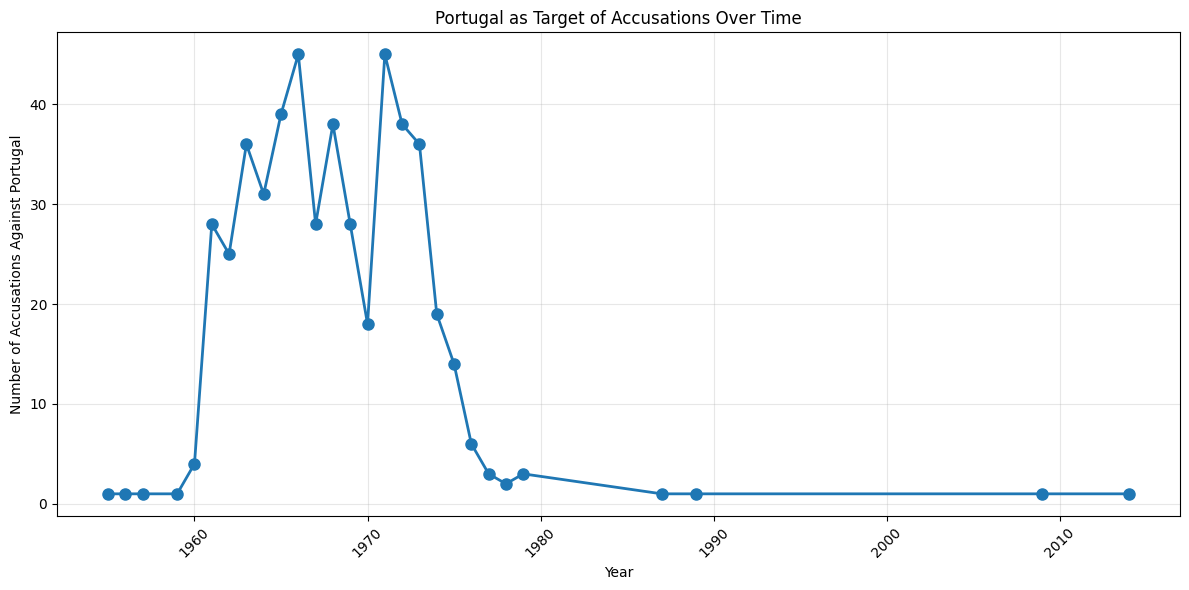

Portugal as target by year:
    year  count
0   1955      1
1   1956      1
2   1957      1
3   1959      1
4   1960      4
5   1961     28
6   1962     25
7   1963     36
8   1964     31
9   1965     39
10  1966     45
11  1967     28
12  1968     38
13  1969     28
14  1970     18
15  1971     45
16  1972     38
17  1973     36
18  1974     19
19  1975     14
20  1976      6
21  1977      3
22  1978      2
23  1979      3
24  1987      1
25  1989      1
26  2009      1
27  2014      1


In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter for rows where PRT is the target
prt_target = graph[graph['target'] == 'PRT']

# Count occurrences by year
prt_by_year = prt_target.groupby('year').size().reset_index(name='count')

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(prt_by_year['year'], prt_by_year['count'], marker='o', linewidth=2, markersize=8)
plt.xlabel('Year')
plt.ylabel('Number of Accusations Against Portugal')
plt.title('Portugal as Target of Accusations Over Time')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Add some styling
plt.tight_layout()
plt.show()

# Also show the data
print("Portugal as target by year:")
print(prt_by_year)

In [18]:
# Get all accusations that target Portugal
prt_accusations = graph[graph['target'] == 'PRT']

# For each accusation against Portugal, see what other states that same source accuses in the same year
co_accused_states = []

for _, prt_row in prt_accusations.iterrows():
    source = prt_row['source']
    year = prt_row['year']
    
    # Find other accusations by same source in same year
    same_year_accusations = graph[
        (graph['source'] == source) & 
        (graph['year'] == year) & 
        (graph['target'] != 'PRT')  # Exclude Portugal itself
    ]
    
    for _, other_row in same_year_accusations.iterrows():
        co_accused_states.append({
            'source': source,
            'year': year,
            'co_accused': other_row['target']
        })

# Convert to DataFrame and analyze
co_accused_df = pd.DataFrame(co_accused_states)

if len(co_accused_df) > 0:
    print("States co-accused alongside Portugal:")
    co_accused_counts = co_accused_df['co_accused'].value_counts()
    print(co_accused_counts.head(15))
    
    print(f"\nBreakdown by source-year:")
    for source in co_accused_df['source'].unique()[:10]:  # Top 10 sources
        source_data = co_accused_df[co_accused_df['source'] == source]
        if len(source_data) > 0:
            print(f"\n{source} co-accuses Portugal with:")
            source_counts = source_data['co_accused'].value_counts()
            print(f"  {dict(source_counts.head(5))}")
else:
    print("No co-accusations found in same year")

States co-accused alongside Portugal:
co_accused
ZAF    432
RHO    320
ISR    179
USA    151
GBR    114
FRA     46
DEU     43
RUS     31
CHN     26
BEL     23
ESP     16
VNM     15
IDN     10
ZWE     10
JPN      9
Name: count, dtype: int64

Breakdown by source-year:

CIV co-accuses Portugal with:
  {'ZAF': np.int64(3), 'CHN': np.int64(2), 'RHO': np.int64(2), 'DEU': np.int64(1), 'USA': np.int64(1)}

BFA co-accuses Portugal with:
  {'ZAF': np.int64(7), 'RHO': np.int64(6), 'USA': np.int64(2), 'RUS': np.int64(1), 'ESP': np.int64(1)}

KWT co-accuses Portugal with:
  {'RHO': np.int64(1), 'USA': np.int64(1), 'ISR': np.int64(1), 'ZAF': np.int64(1)}

KEN co-accuses Portugal with:
  {'ZAF': np.int64(8), 'RHO': np.int64(7), 'USA': np.int64(5), 'GBR': np.int64(4), 'ISR': np.int64(2)}

BGR co-accuses Portugal with:
  {'ZAF': np.int64(6), 'USA': np.int64(6), 'DEU': np.int64(5), 'RHO': np.int64(4), 'ISR': np.int64(2)}

PAK co-accuses Portugal with:
  {'IND': np.int64(5), 'ZAF': np.int64(5), 'ISR': np

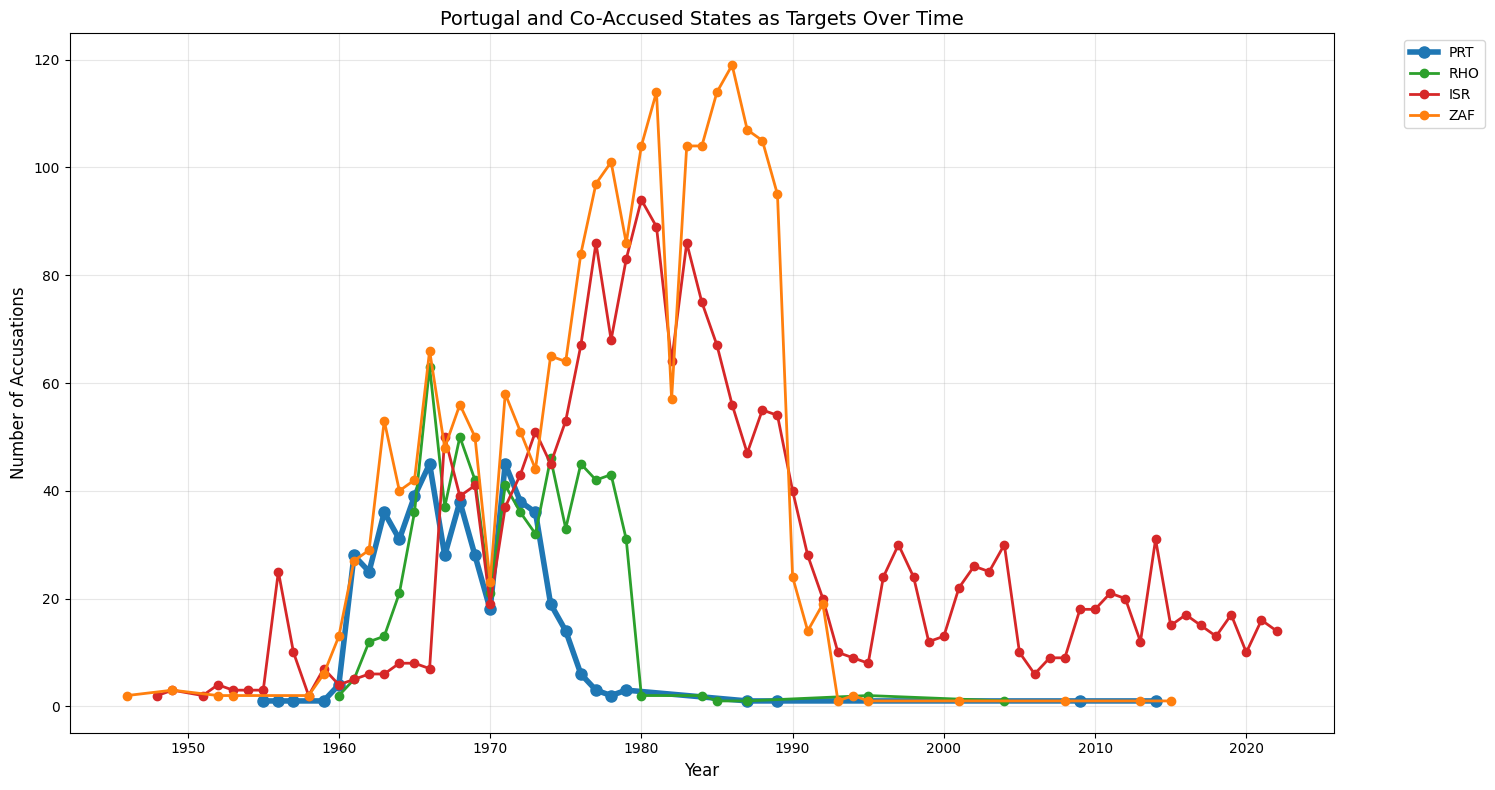

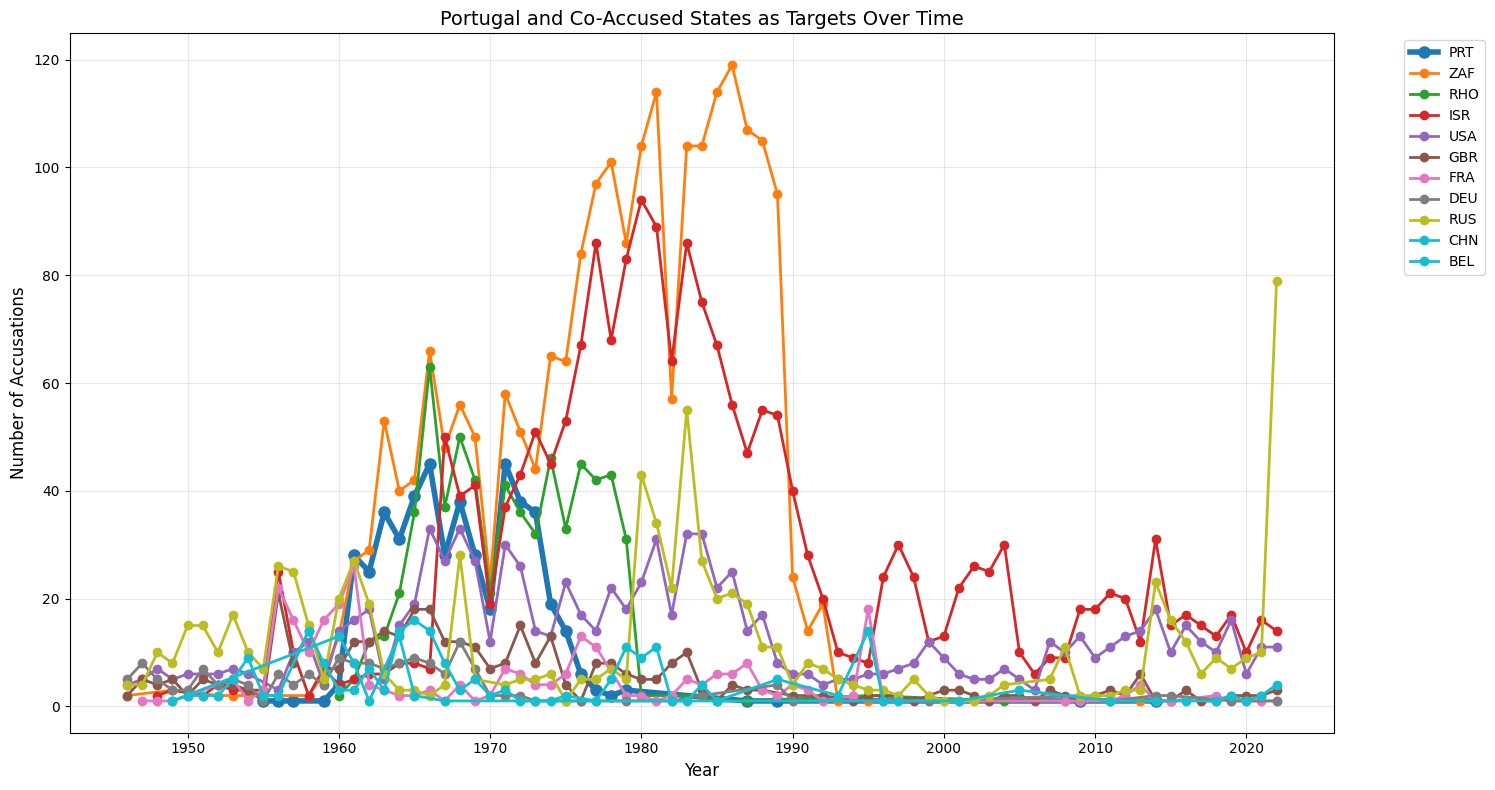

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Get the co-accused countries
top_co_accused = ['ZAF', 'RHO', 'ISR', 'USA', 'GBR', 'FRA', 'DEU', 'RUS', 'CHN', 'BEL']
countries_to_plot = ['PRT'] + top_co_accused

# Create time series data for each country
country_data = {}
for country in countries_to_plot:
    country_target = graph[graph['target'] == country]
    country_by_year = country_target.groupby('year').size().reset_index(name='count')
    country_data[country] = country_by_year

# Function to plot selected countries
def plot_countries(selected_countries):
    plt.figure(figsize=(15, 8))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(countries_to_plot)))
    color_map = dict(zip(countries_to_plot, colors))
    
    for country in selected_countries:
        if country in country_data and len(country_data[country]) > 0:
            data = country_data[country]
            
            # Make Portugal line thicker
            linewidth = 4 if country == 'PRT' else 2
            markersize = 8 if country == 'PRT' else 6
            
            plt.plot(data['year'], data['count'], 
                    marker='o', linewidth=linewidth, markersize=markersize,
                    label=country, color=color_map[country])
    
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Number of Accusations', fontsize=12)
    plt.title('Portugal and Co-Accused States as Targets Over Time', fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Now you can easily plot different combinations:

# Portugal + South Africa + Rhodesia (colonial trio)
plot_countries(['PRT', 'RHO', 'ISR', 'ZAF'])

# All countries
plot_countries(countries_to_plot)



In [30]:
# Filter data for the period 1960-1980
period_data = graph[(graph['year'] >= 1960) & (graph['year'] <= 1980)]

# Total accusations in this period
total_accusations = len(period_data)

# Accusations against the specific countries
target_countries = ['ZAF', 'ISR', 'RHO', 'PRT']
accusations_against_targets = period_data[period_data['target'].isin(target_countries)]
target_accusations_count = len(accusations_against_targets)

# Calculate proportion
proportion = target_accusations_count / total_accusations

print(f"Period: 1960-1980")
print(f"Total accusations: {total_accusations}")
print(f"Accusations against ZAF, ISR, RHO, PRT: {target_accusations_count}")
print(f"Proportion: {proportion:.3f} ({proportion*100:.1f}%)")

# Breakdown by individual country
print("\nBreakdown by country:")
for country in target_countries:
    country_count = len(period_data[period_data['target'] == country])
    country_prop = country_count / total_accusations
    print(f"{country}: {country_count} accusations ({country_prop*100:.1f}%)")

# Show yearly breakdown
yearly_breakdown = period_data[period_data['target'].isin(target_countries)].groupby(['year', 'target']).size().unstack(fill_value=0)
print(f"\nYearly breakdown:")
print(yearly_breakdown)

# Calculate proportion by year
yearly_totals = period_data.groupby('year').size()
yearly_target_totals = period_data[period_data['target'].isin(target_countries)].groupby('year').size()
yearly_proportions = (yearly_target_totals / yearly_totals * 100).round(1)

print(f"\nProportion by year (%):")
print(yearly_proportions)

Period: 1960-1980
Total accusations: 5218
Accusations against ZAF, ISR, RHO, PRT: 3160
Proportion: 0.606 (60.6%)

Breakdown by country:
ZAF: 1201 accusations (23.0%)
ISR: 820 accusations (15.7%)
RHO: 653 accusations (12.5%)
PRT: 486 accusations (9.3%)

Yearly breakdown:
target  ISR  PRT  RHO  ZAF
year                      
1960      4    4    2   13
1961      5   28    5   27
1962      6   25   12   29
1963      6   36   13   53
1964      8   31   21   40
1965      8   39   36   42
1966      7   45   63   66
1967     50   28   37   48
1968     39   38   50   56
1969     41   28   42   50
1970     19   18   21   23
1971     37   45   41   58
1972     43   38   36   51
1973     51   36   32   44
1974     45   19   46   65
1975     53   14   33   64
1976     67    6   45   84
1977     86    3   42   97
1978     68    2   43  101
1979     83    3   31   86
1980     94    0    2  104

Proportion by year (%):
year
1960    16.7
1961    34.8
1962    40.2
1963    63.5
1964    52.1
1965    56.8


In [32]:
# Filter data for the period 1960-1980
period_data = graph[(graph['year'] >= 1960) & (graph['year'] <= 1980)]

# The four countries we're analyzing (treating RHO and NAM as the same)
source_countries = ['ZAF', 'ISR', 'RHO', 'PRT']

# Create a copy of the data and standardize RHO/NAM
period_data_clean = period_data.copy()
period_data_clean['source'] = period_data_clean['source'].replace('NAM', 'RHO')
period_data_clean['target'] = period_data_clean['target'].replace('NAM', 'RHO')

# Get accusations made BY these countries
accusations_by_sources = period_data_clean[period_data_clean['source'].isin(source_countries)]

print(f"Period: 1960-1980")
print(f"Total accusations made by ZAF, ISR, RHO/NAM, PRT: {len(accusations_by_sources)}")

# Breakdown by source country
print("\nAccusations made by each country:")
for country in source_countries:
    country_accusations = accusations_by_sources[accusations_by_sources['source'] == country]
    print(f"{country}: {len(country_accusations)} accusations")

# Who do they accuse most often?
print("\nMost frequently accused targets by these four countries:")
target_counts = accusations_by_sources['target'].value_counts()
print(target_counts.head(15))

# Do they accuse the same states? (overlap analysis)
print("\nOverlap analysis - targets accused by multiple source countries:")

# Create a matrix showing which sources accuse which targets
accusation_matrix = accusations_by_sources.pivot_table(
    index='source', 
    columns='target', 
    values='year', 
    aggfunc='count', 
    fill_value=0
)

# Find targets accused by multiple sources
targets_by_multiple = (accusation_matrix > 0).sum(axis=0)
shared_targets = targets_by_multiple[targets_by_multiple > 1].sort_values(ascending=False)

print("Targets accused by multiple countries:")
for target, count in shared_targets.head(10).items():
    accusers = accusation_matrix.index[accusation_matrix[target] > 0].tolist()
    total_accusations = accusation_matrix[target].sum()
    print(f"{target}: accused by {count} countries ({', '.join(accusers)}) - {total_accusations} total accusations")

# Show detailed breakdown for top shared targets
print(f"\nDetailed breakdown for most shared targets:")
for target in shared_targets.head(5).index:
    print(f"\n{target}:")
    for source in source_countries:
        if source in accusation_matrix.index and target in accusation_matrix.columns:
            if accusation_matrix.loc[source, target] > 0:
                count = accusation_matrix.loc[source, target]
                print(f"  {source}: {count} accusations")

# Calculate similarity between countries based on their accusation patterns
print(f"\nAccusation pattern similarity (correlation):")
if len(accusation_matrix) > 1:
    correlation_matrix = accusation_matrix.T.corr()
    print(correlation_matrix.round(3))
else:
    print("Not enough data for correlation analysis")

Period: 1960-1980
Total accusations made by ZAF, ISR, RHO/NAM, PRT: 90

Accusations made by each country:
ZAF: 10 accusations
ISR: 64 accusations
RHO: 0 accusations
PRT: 16 accusations

Most frequently accused targets by these four countries:
target
RUS    15
EGY    12
SYR    11
PSE     7
IND     5
ISR     3
RHO     3
IRQ     3
JOR     3
IRN     2
USA     2
LBY     2
ZAF     2
CHN     2
PRT     2
Name: count, dtype: int64

Overlap analysis - targets accused by multiple source countries:
Targets accused by multiple countries:
RUS: accused by 3 countries (ISR, PRT, ZAF) - 15 total accusations
IND: accused by 2 countries (PRT, ZAF) - 5 total accusations
IRN: accused by 2 countries (ISR, PRT) - 2 total accusations
RHO: accused by 2 countries (ISR, PRT) - 3 total accusations
USA: accused by 2 countries (ISR, ZAF) - 2 total accusations
ZAF: accused by 2 countries (ISR, PRT) - 2 total accusations

Detailed breakdown for most shared targets:

RUS:
  ZAF: 2 accusations
  ISR: 11 accusations
  P

Accusation matrix shape: (96, 151)
Target countries: 96
Source countries: 151
Frequently accused targets (>=10 accusations): 34
Countries: ['BEL', 'CHL', 'CHN', 'CSK', 'CUB', 'DEU', 'EGY', 'ESP', 'FRA', 'GBR', 'GRC', 'GTM', 'IDN', 'IND', 'IRN', 'IRQ', 'ISR', 'JPN', 'KHM', 'KOR', 'LBN', 'MAR', 'PAK', 'PRT', 'PSE', 'RHO', 'RUS', 'SYR', 'THA', 'TUR', 'USA', 'VNM', 'ZAF', 'ZWE']


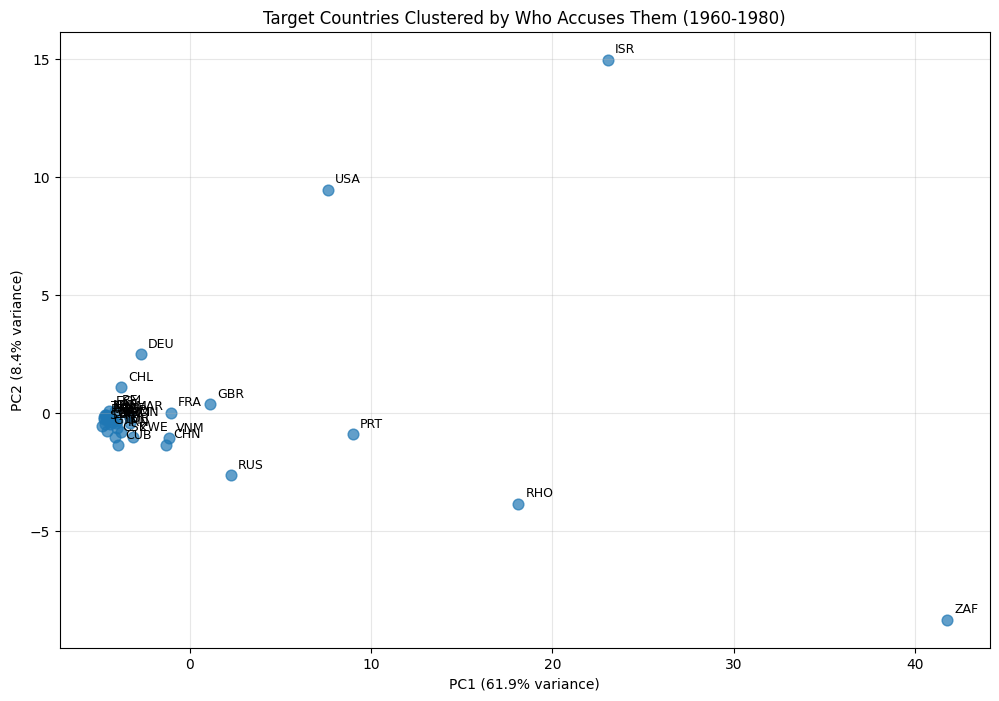

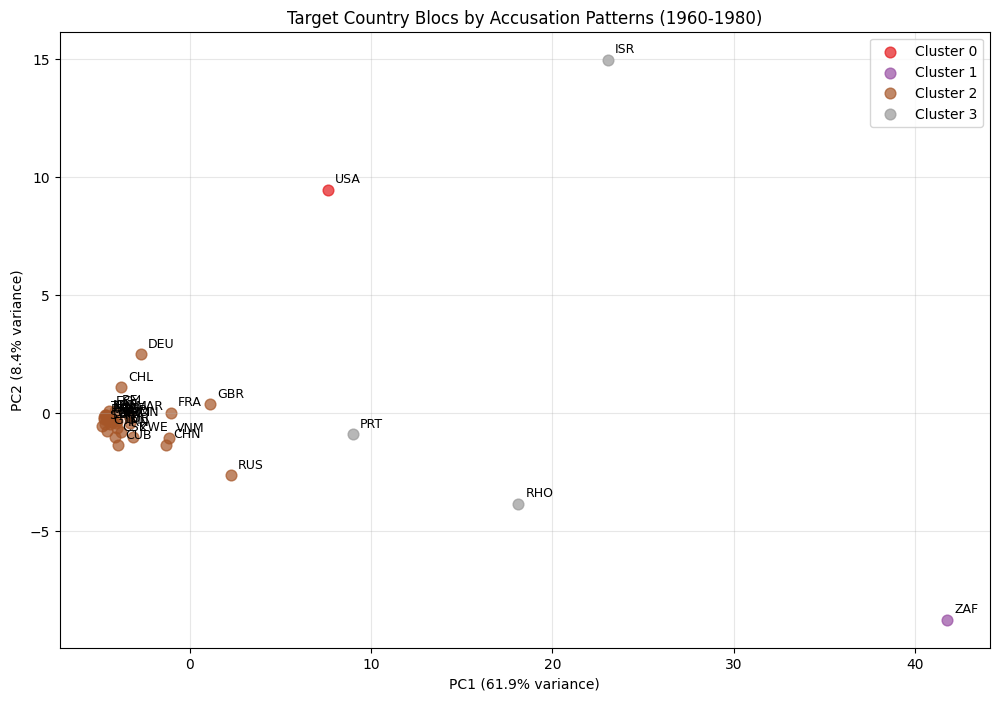


Clustering results (4 clusters):
Cluster 0: ['USA']
Cluster 1: ['ZAF']
Cluster 2: ['BEL', 'CHL', 'CHN', 'CSK', 'CUB', 'DEU', 'EGY', 'ESP', 'FRA', 'GBR', 'GRC', 'GTM', 'IDN', 'IND', 'IRN', 'IRQ', 'JPN', 'KHM', 'KOR', 'LBN', 'MAR', 'PAK', 'PSE', 'RUS', 'SYR', 'THA', 'TUR', 'VNM', 'ZWE']
Cluster 3: ['ISR', 'PRT', 'RHO']

Cluster characteristics (who accuses them):

Cluster 0 (USA):
Typically accused by:
  CUB: 20.0 avg accusations
  ALB: 16.0 avg accusations
  BLR: 14.0 avg accusations
  IRQ: 14.0 avg accusations
  KHM: 13.0 avg accusations
  RUS: 13.0 avg accusations
  HUN: 12.0 avg accusations
  COG: 12.0 avg accusations

Cluster 1 (ZAF):
Typically accused by:
  LBR: 21.0 avg accusations
  SLE: 19.0 avg accusations
  LBY: 19.0 avg accusations
  NGA: 19.0 avg accusations
  SDN: 19.0 avg accusations
  ETH: 19.0 avg accusations
  GHA: 18.0 avg accusations
  GIN: 17.0 avg accusations

Cluster 2 (BEL, CHL, CHN, CSK, CUB, DEU, EGY, ESP, FRA, GBR, GRC, GTM, IDN, IND, IRN, IRQ, JPN, KHM, KOR, 

In [35]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Filter data for 1960-1980
period_data = graph[(graph['year'] >= 1960) & (graph['year'] <= 1980)]

# Standardize RHO/NAM
period_data_clean = period_data.copy()
period_data_clean['target'] = period_data_clean['target'].replace('NAM', 'RHO')

# Create accusation matrix: rows = TARGET countries, columns = SOURCE countries
# (This is the transpose of what I did before)
accusation_matrix = period_data_clean.pivot_table(
    index='target',  # Targets as rows
    columns='source',  # Sources as columns
    values='year', 
    aggfunc='count', 
    fill_value=0
)

print(f"Accusation matrix shape: {accusation_matrix.shape}")
print(f"Target countries: {len(accusation_matrix)}")
print(f"Source countries: {len(accusation_matrix.columns)}")

# Only include targets that are accused at least 10 times (to filter noise)
min_accusations = 10
frequently_accused = accusation_matrix[accusation_matrix.sum(axis=1) >= min_accusations]
print(f"Frequently accused targets (>={min_accusations} accusations): {len(frequently_accused)}")
print(f"Countries: {list(frequently_accused.index)}")

# PCA to reduce dimensionality
scaler = StandardScaler()
accusation_scaled = scaler.fit_transform(frequently_accused)

pca = PCA(n_components=2)
accusation_pca = pca.fit_transform(accusation_scaled)

# Create scatter plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(accusation_pca[:, 0], accusation_pca[:, 1], alpha=0.7, s=60)

# Label points with country codes
for i, country in enumerate(frequently_accused.index):
    plt.annotate(country, (accusation_pca[i, 0], accusation_pca[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Target Countries Clustered by Who Accuses Them (1960-1980)')
plt.grid(True, alpha=0.3)
plt.show()

# K-means clustering to identify target blocs
n_clusters = 4  # Adjust this number
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(accusation_scaled)

# Colored scatter plot by cluster
plt.figure(figsize=(12, 8))
colors = plt.cm.Set1(np.linspace(0, 1, n_clusters))

for cluster_id in range(n_clusters):
    mask = clusters == cluster_id
    plt.scatter(accusation_pca[mask, 0], accusation_pca[mask, 1], 
               c=[colors[cluster_id]], label=f'Cluster {cluster_id}', s=60, alpha=0.7)
    
    # Label points
    cluster_indices = np.where(mask)[0]
    for i in cluster_indices:
        country = frequently_accused.index[i]
        plt.annotate(country, (accusation_pca[i, 0], accusation_pca[i, 1]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Target Country Blocs by Accusation Patterns (1960-1980)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Show cluster results
print(f"\nClustering results ({n_clusters} clusters):")
for cluster_id in range(n_clusters):
    cluster_countries = frequently_accused.index[clusters == cluster_id].tolist()
    print(f"Cluster {cluster_id}: {cluster_countries}")

# Analyze who typically accuses each cluster
print(f"\nCluster characteristics (who accuses them):")
for cluster_id in range(n_clusters):
    cluster_mask = clusters == cluster_id
    cluster_countries = frequently_accused.index[cluster_mask]
    
    # Average accusation pattern for this cluster
    cluster_accusers = frequently_accused.loc[cluster_countries].mean(axis=0).sort_values(ascending=False)
    
    print(f"\nCluster {cluster_id} ({', '.join(cluster_countries)}):")
    print("Typically accused by:")
    for accuser, avg_accusations in cluster_accusers.head(8).items():
        if avg_accusations > 0.5:  # Only show meaningful accusers
            print(f"  {accuser}: {avg_accusations:.1f} avg accusations")

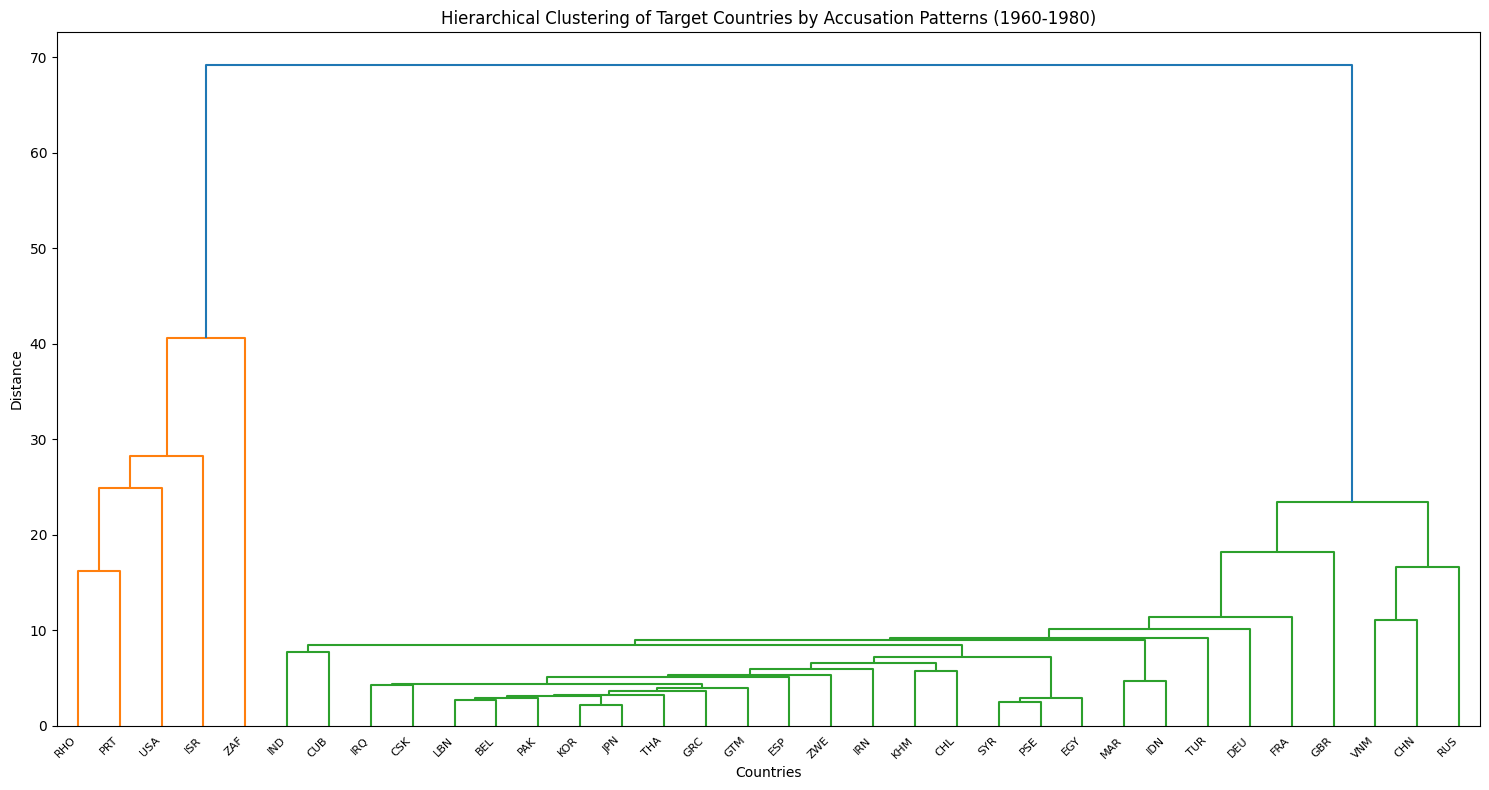

Hierarchical clustering at different levels:

2 Clusters:
  Cluster 1: ['BEL', 'CHL', 'CHN', 'CSK', 'CUB', 'DEU', 'EGY', 'ESP', 'FRA', 'GBR', 'GRC', 'GTM', 'IDN', 'IND', 'IRN', 'IRQ', 'JPN', 'KHM', 'KOR', 'LBN', 'MAR', 'PAK', 'PSE', 'RUS', 'SYR', 'THA', 'TUR', 'VNM', 'ZWE']
  Cluster 2: ['ISR', 'PRT', 'RHO', 'USA', 'ZAF']

3 Clusters:
  Cluster 1: ['BEL', 'CHL', 'CHN', 'CSK', 'CUB', 'DEU', 'EGY', 'ESP', 'FRA', 'GBR', 'GRC', 'GTM', 'IDN', 'IND', 'IRN', 'IRQ', 'JPN', 'KHM', 'KOR', 'LBN', 'MAR', 'PAK', 'PSE', 'RUS', 'SYR', 'THA', 'TUR', 'VNM', 'ZWE']
  Cluster 2: ['ISR', 'PRT', 'RHO', 'USA']
  Cluster 3: ['ZAF']

4 Clusters:
  Cluster 1: ['BEL', 'CHL', 'CHN', 'CSK', 'CUB', 'DEU', 'EGY', 'ESP', 'FRA', 'GBR', 'GRC', 'GTM', 'IDN', 'IND', 'IRN', 'IRQ', 'JPN', 'KHM', 'KOR', 'LBN', 'MAR', 'PAK', 'PSE', 'RUS', 'SYR', 'THA', 'TUR', 'VNM', 'ZWE']
  Cluster 2: ['PRT', 'RHO', 'USA']
  Cluster 3: ['ISR']
  Cluster 4: ['ZAF']

Anti-Colonial/Apartheid Bloc (3-cluster solution): ['ISR', 'PRT', 'RHO', 'U

In [36]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

# Use the same data from before
frequently_accused = accusation_matrix[accusation_matrix.sum(axis=1) >= 10]

# Standardize the data
scaler = StandardScaler()
accusation_scaled = scaler.fit_transform(frequently_accused)

# Hierarchical clustering
linkage_matrix = linkage(accusation_scaled, method='ward')

# Create dendrogram
plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, 
           labels=frequently_accused.index.tolist(),
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering of Target Countries by Accusation Patterns (1960-1980)')
plt.xlabel('Countries')
plt.ylabel('Distance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Get clusters at different levels
print("Hierarchical clustering at different levels:")

# 2 clusters (major split)
clusters_2 = fcluster(linkage_matrix, 2, criterion='maxclust')
print(f"\n2 Clusters:")
for i in range(1, 3):
    cluster_countries = frequently_accused.index[clusters_2 == i].tolist()
    print(f"  Cluster {i}: {cluster_countries}")

# 3 clusters 
clusters_3 = fcluster(linkage_matrix, 3, criterion='maxclust')
print(f"\n3 Clusters:")
for i in range(1, 4):
    cluster_countries = frequently_accused.index[clusters_3 == i].tolist()
    print(f"  Cluster {i}: {cluster_countries}")

# 4 clusters (what we had before)
clusters_4 = fcluster(linkage_matrix, 4, criterion='maxclust')
print(f"\n4 Clusters:")
for i in range(1, 5):
    cluster_countries = frequently_accused.index[clusters_4 == i].tolist()
    print(f"  Cluster {i}: {cluster_countries}")

# Analyze the anti-colonial/apartheid bloc
anti_colonial_countries = []
for i in range(1, 4):  # Check 3-cluster solution
    cluster_countries = frequently_accused.index[clusters_3 == i].tolist()
    if any(country in ['ZAF', 'ISR', 'PRT', 'RHO'] for country in cluster_countries):
        anti_colonial_countries.extend(cluster_countries)

if anti_colonial_countries:
    print(f"\nAnti-Colonial/Apartheid Bloc (3-cluster solution): {anti_colonial_countries}")
    
    # Calculate total accusations against this bloc
    bloc_accusations = period_data_clean[period_data_clean['target'].isin(anti_colonial_countries)]
    total_bloc_accusations = len(bloc_accusations)
    total_period_accusations = len(period_data_clean)
    
    print(f"Total accusations against Anti-Colonial/Apartheid bloc: {total_bloc_accusations}")
    print(f"Percentage of all accusations (1960-1980): {total_bloc_accusations/total_period_accusations*100:.1f}%")
    
    # Compare to USA (Cold War target)
    usa_accusations = len(period_data_clean[period_data_clean['target'] == 'USA'])
    print(f"USA accusations for comparison: {usa_accusations}")
    print(f"Anti-Colonial bloc vs USA ratio: {total_bloc_accusations/usa_accusations:.1f}:1")

# Show who accuses the combined anti-colonial bloc
if anti_colonial_countries:
    print(f"\nWho accuses the Anti-Colonial/Apartheid bloc:")
    bloc_data = frequently_accused.loc[anti_colonial_countries]
    average_accusers = bloc_data.mean(axis=0).sort_values(ascending=False)
    
    for accuser, avg in average_accusers.head(15).items():
        if avg > 1:
            print(f"  {accuser}: {avg:.1f} avg accusations")

In [37]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.pyplot as plt

def analyze_period_clustering(start_year, end_year, min_accusations=10, n_clusters=4):
    """
    Analyze accusation clustering patterns for a specific time period
    """
    # Filter data for the period
    period_data = graph[(graph['year'] >= start_year) & (graph['year'] <= end_year)]
    
    if len(period_data) == 0:
        return None
    
    # Create accusation matrix
    accusation_matrix = period_data.pivot_table(
        index='target', 
        columns='source', 
        values='year', 
        aggfunc='count', 
        fill_value=0
    )
    
    # Filter for frequently accused countries
    frequently_accused = accusation_matrix[accusation_matrix.sum(axis=1) >= min_accusations]
    
    if len(frequently_accused) < 3:  # Need at least 3 countries for meaningful clustering
        return None
    
    # Standardize and cluster
    scaler = StandardScaler()
    accusation_scaled = scaler.fit_transform(frequently_accused)
    linkage_matrix = linkage(accusation_scaled, method='ward')
    clusters = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
    
    # Calculate clustering metrics
    total_accusations = len(period_data)
    
    # Find the largest cluster
    cluster_sizes = {}
    for i in range(1, n_clusters + 1):
        cluster_countries = frequently_accused.index[clusters == i].tolist()
        cluster_accusations = period_data[period_data['target'].isin(cluster_countries)]
        cluster_size = len(cluster_accusations)
        cluster_sizes[i] = {
            'countries': cluster_countries,
            'accusations': cluster_size,
            'percentage': cluster_size / total_accusations * 100
        }
    
    return {
        'period': f"{start_year}-{end_year}",
        'total_accusations': total_accusations,
        'frequently_accused': frequently_accused.index.tolist(),
        'clusters': cluster_sizes,
        'accusation_matrix': frequently_accused
    }

# Systematic analysis across different periods
periods_to_analyze = [
    (1946, 1959),  # Early UN period
    (1960, 1969),  # Early decolonization
    (1970, 1979),  # Peak decolonization/Cold War
    (1980, 1989),  # Late Cold War
    (1990, 1999),  # Post-Cold War
    (2000, 2009),  # War on Terror era
    (2010, 2020),  # Contemporary period
]

print("=== SYSTEMATIC CLUSTERING ANALYSIS ACROSS TIME PERIODS ===\n")

period_results = {}
for start, end in periods_to_analyze:
    result = analyze_period_clustering(start, end)
    if result:
        period_results[f"{start}-{end}"] = result
        
        print(f"Period: {start}-{end}")
        print(f"Total accusations: {result['total_accusations']}")
        print(f"Countries with ≥10 accusations: {len(result['frequently_accused'])}")
        
        # Find dominant cluster
        dominant_cluster = max(result['clusters'].items(), key=lambda x: x[1]['percentage'])
        print(f"Dominant cluster: {dominant_cluster[1]['countries']} ({dominant_cluster[1]['percentage']:.1f}%)")
        
        # Show all clusters
        for cluster_id, cluster_info in result['clusters'].items():
            if cluster_info['percentage'] > 5:  # Only show significant clusters
                print(f"  Cluster {cluster_id}: {cluster_info['countries']} ({cluster_info['percentage']:.1f}%)")
        print()

# Advanced analysis: Look for "bipolar" vs "unipolar" structures
print("=== STRUCTURAL ANALYSIS ===\n")

for period, result in period_results.items():
    clusters = result['clusters']
    
    # Calculate concentration (how evenly distributed accusations are across clusters)
    percentages = [c['percentage'] for c in clusters.values()]
    max_percentage = max(percentages)
    second_max = sorted(percentages, reverse=True)[1] if len(percentages) > 1 else 0
    
    # Classification
    if max_percentage > 60:
        structure = "HEGEMONIC" 
    elif max_percentage > 40 and second_max > 20:
        structure = "BIPOLAR"
    elif max_percentage < 40:
        structure = "MULTIPOLAR"
    else:
        structure = "DOMINANT"
    
    print(f"{period}: {structure} (largest: {max_percentage:.1f}%, second: {second_max:.1f}%)")

# Function to find "similar periods" based on which countries are heavily targeted
def find_similar_periods(target_countries, threshold=2):
    """
    Find periods where a similar set of countries are heavily targeted
    """
    similar_periods = []
    
    for period, result in period_results.items():
        # Count how many of our target countries appear in this period's top targets
        overlap = len(set(target_countries) & set(result['frequently_accused']))
        if overlap >= threshold:
            similar_periods.append((period, overlap))
    
    return sorted(similar_periods, key=lambda x: x[1], reverse=True)

# Look for periods similar to our 1960-1980 discovery
colonial_targets = ['PRT', 'RHO', 'ISR', 'ZAF', 'USA']
print(f"\n=== PERIODS WITH SIMILAR TARGETS TO 1960-1980 ===")
similar = find_similar_periods(colonial_targets, threshold=3)
for period, overlap in similar:
    print(f"{period}: {overlap}/5 countries overlap")

=== SYSTEMATIC CLUSTERING ANALYSIS ACROSS TIME PERIODS ===

Period: 1946-1959
Total accusations: 871
Countries with ≥10 accusations: 15
Dominant cluster: ['FRA', 'GBR', 'ISR'] (26.3%)
  Cluster 1: ['FRA', 'GBR', 'ISR'] (26.3%)
  Cluster 2: ['DEU', 'USA'] (16.8%)
  Cluster 3: ['CHN', 'EGY', 'HUN', 'IND', 'ITA', 'JPN', 'NLD', 'PRK', 'ZAF'] (22.3%)
  Cluster 4: ['RUS'] (19.6%)

Period: 1960-1969
Total accusations: 2217
Countries with ≥10 accusations: 19
Dominant cluster: ['PRT', 'RHO', 'ZAF'] (45.4%)
  Cluster 1: ['PRT', 'RHO', 'ZAF'] (45.4%)
  Cluster 2: ['GBR', 'ISR', 'USA'] (23.0%)
  Cluster 3: ['BEL', 'CHN', 'CSK', 'CUB', 'DEU', 'ESP', 'FRA', 'IDN', 'IND', 'JPN', 'THA', 'VNM'] (19.6%)
  Cluster 4: ['RUS'] (5.3%)

Period: 1970-1979
Total accusations: 2580
Countries with ≥10 accusations: 22
Dominant cluster: ['ISR', 'RHO'] (35.7%)
  Cluster 1: ['CHL', 'CHN', 'DEU', 'EGY', 'ESP', 'FRA', 'GBR', 'GRC', 'IDN', 'MAR', 'NAM', 'PRT', 'PSE', 'RUS', 'SYR', 'TUR', 'VNM', 'ZWE'] (25.3%)
  Cluster 

In [38]:
# Define the two periods
early_period = graph[(graph['year'] >= 1946) & (graph['year'] <= 1959)]
decolonization_period = graph[(graph['year'] >= 1960) & (graph['year'] <= 1980)]

# Calculate accusations per year for each country in each period
def accusations_per_year(period_data):
    period_years = period_data['year'].max() - period_data['year'].min() + 1
    country_counts = period_data['target'].value_counts()
    return country_counts / period_years

early_rates = accusations_per_year(early_period)
decolonization_rates = accusations_per_year(decolonization_period)

# Find countries that were prominent in early period but dropped off
print("Countries with unique 1946-1959 temporal dynamics:")
print("(High early period rate, low decolonization rate)\n")

# Create comparison dataframe
comparison = pd.DataFrame({
    'early_rate': early_rates,
    'decolonization_rate': decolonization_rates
}).fillna(0)

# Calculate the ratio (early rate / decolonization rate)
# Add small value to avoid division by zero
comparison['ratio'] = comparison['early_rate'] / (comparison['decolonization_rate'] + 0.1)

# Filter for countries that:
# 1. Had meaningful presence in early period (>= 0.5 accusations per year)
# 2. Had high ratio (early rate much higher than decolonization rate)
candidates = comparison[
    (comparison['early_rate'] >= 0.5) & 
    (comparison['ratio'] >= 2.0)
].sort_values('ratio', ascending=False)

print("Top candidates (early rate >= 0.5, ratio >= 2.0):")
for country, row in candidates.head(10).iterrows():
    print(f"{country}: {row['early_rate']:.1f} per year (1946-59) vs {row['decolonization_rate']:.1f} per year (1960-80), ratio: {row['ratio']:.1f}")

# Also look at absolute numbers for context
print(f"\nWith absolute numbers:")
for country, row in candidates.head(10).iterrows():
    early_total = early_period[early_period['target'] == country].shape[0]
    decolonization_total = decolonization_period[decolonization_period['target'] == country].shape[0]
    print(f"{country}: {early_total} total (1946-59) vs {decolonization_total} total (1960-80)")

# Show countries that completely disappeared after 1959
print(f"\nCountries that disappeared completely after 1959:")
disappeared = early_rates[~early_rates.index.isin(decolonization_rates.index)]
disappeared_significant = disappeared[disappeared >= 0.5].sort_values(ascending=False)
for country, rate in disappeared_significant.head(10).items():
    total = early_period[early_period['target'] == country].shape[0]
    print(f"{country}: {rate:.1f} per year ({total} total), then zero")

Countries with unique 1946-1959 temporal dynamics:
(High early period rate, low decolonization rate)

Top candidates (early rate >= 0.5, ratio >= 2.0):
HUN: 1.9 per year (1946-59) vs 0.1 per year (1960-80), ratio: 7.6
YUG: 0.6 per year (1946-59) vs 0.0 per year (1960-80), ratio: 6.4
ALB: 0.6 per year (1946-59) vs 0.0 per year (1960-80), ratio: 4.4
PRK: 1.9 per year (1946-59) vs 0.3 per year (1960-80), ratio: 4.3
BGR: 0.6 per year (1946-59) vs 0.0 per year (1960-80), ratio: 3.9
JPN: 1.7 per year (1946-59) vs 0.7 per year (1960-80), ratio: 2.1

With absolute numbers:
HUN: 26 total (1946-59) vs 3 total (1960-80)
YUG: 9 total (1946-59) vs 0 total (1960-80)
ALB: 9 total (1946-59) vs 1 total (1960-80)
PRK: 26 total (1946-59) vs 7 total (1960-80)
BGR: 8 total (1946-59) vs 1 total (1960-80)
JPN: 24 total (1946-59) vs 15 total (1960-80)

Countries that disappeared completely after 1959:
YUG: 0.6 per year (9 total), then zero


In [39]:
# Filter for early period (1946-1959)
early_period = graph[(graph['year'] >= 1946) & (graph['year'] <= 1959)]

# The countries with unique early dynamics
early_targets = ['HUN', 'YUG', 'ALB', 'PRK', 'BGR', 'JPN']

# For each accusation against these countries, see what other states that same source accuses in the same year
co_accused_states = []

for target_country in early_targets:
    country_accusations = early_period[early_period['target'] == target_country]
    
    for _, row in country_accusations.iterrows():
        source = row['source']
        year = row['year']
        
        # Find other accusations by same source in same year
        same_year_accusations = early_period[
            (early_period['source'] == source) & 
            (early_period['year'] == year) & 
            (early_period['target'] != target_country)  # Exclude the target itself
        ]
        
        for _, other_row in same_year_accusations.iterrows():
            co_accused_states.append({
                'original_target': target_country,
                'source': source,
                'year': year,
                'co_accused': other_row['target']
            })

# Convert to DataFrame and analyze
co_accused_df = pd.DataFrame(co_accused_states)

print("States co-accused alongside early period targets (1946-1959):")
if len(co_accused_df) > 0:
    co_accused_counts = co_accused_df['co_accused'].value_counts()
    print(co_accused_counts.head(15))
    
    print(f"\nBreakdown by original target:")
    for target in early_targets:
        target_data = co_accused_df[co_accused_df['original_target'] == target]
        if len(target_data) > 0:
            print(f"\n{target} co-accused with:")
            target_counts = target_data['co_accused'].value_counts()
            print(f"  {dict(target_counts.head(8))}")
else:
    print("No co-accusations found")

# Also show who accuses these early targets
print(f"\nWho accuses the early period targets:")
for target in early_targets:
    target_accusations = early_period[early_period['target'] == target]
    if len(target_accusations) > 0:
        accusers = target_accusations['source'].value_counts()
        print(f"\n{target} accused by:")
        for accuser, count in accusers.head(5).items():
            print(f"  {accuser}: {count} times")

States co-accused alongside early period targets (1946-1959):
co_accused
RUS    54
USA    27
DEU    27
GBR    23
CHN    15
FRA    15
ALB    12
BGR    11
ISR    10
ROU     9
ITA     9
YUG     9
PRK     6
EGY     6
GRC     4
Name: count, dtype: int64

Breakdown by original target:

HUN co-accused with:
  {'RUS': np.int64(20), 'FRA': np.int64(9), 'ISR': np.int64(8), 'GBR': np.int64(8), 'EGY': np.int64(5), 'DEU': np.int64(3), 'CHN': np.int64(3), 'BGR': np.int64(2)}

YUG co-accused with:
  {'RUS': np.int64(4), 'DEU': np.int64(4), 'USA': np.int64(4), 'GRC': np.int64(3), 'ALB': np.int64(3), 'BGR': np.int64(3), 'GBR': np.int64(3), 'JPN': np.int64(2)}

ALB co-accused with:
  {'BGR': np.int64(5), 'RUS': np.int64(4), 'YUG': np.int64(3), 'ROU': np.int64(2), 'PRK': np.int64(2), 'CHN': np.int64(2), 'ITA': np.int64(1), 'TUR': np.int64(1)}

PRK co-accused with:
  {'RUS': np.int64(14), 'USA': np.int64(6), 'CHN': np.int64(6), 'ROU': np.int64(2), 'ALB': np.int64(2), 'DEU': np.int64(2), 'PAK': np.int64(1)

Accusation matrix shape: (55, 77)
Target countries: 55
Source countries: 77
Frequently accused targets (>=3 accusations): 31
Countries: ['ALB', 'AUS', 'BGR', 'CHN', 'CUB', 'DEU', 'EGY', 'ESP', 'FRA', 'GBR', 'GRC', 'HUN', 'IDN', 'IND', 'ISR', 'ITA', 'JPN', 'KOR', 'NLD', 'OMN', 'PRK', 'PRT', 'PSE', 'ROU', 'RUS', 'SYR', 'TWN', 'USA', 'VNM', 'YUG', 'ZAF']


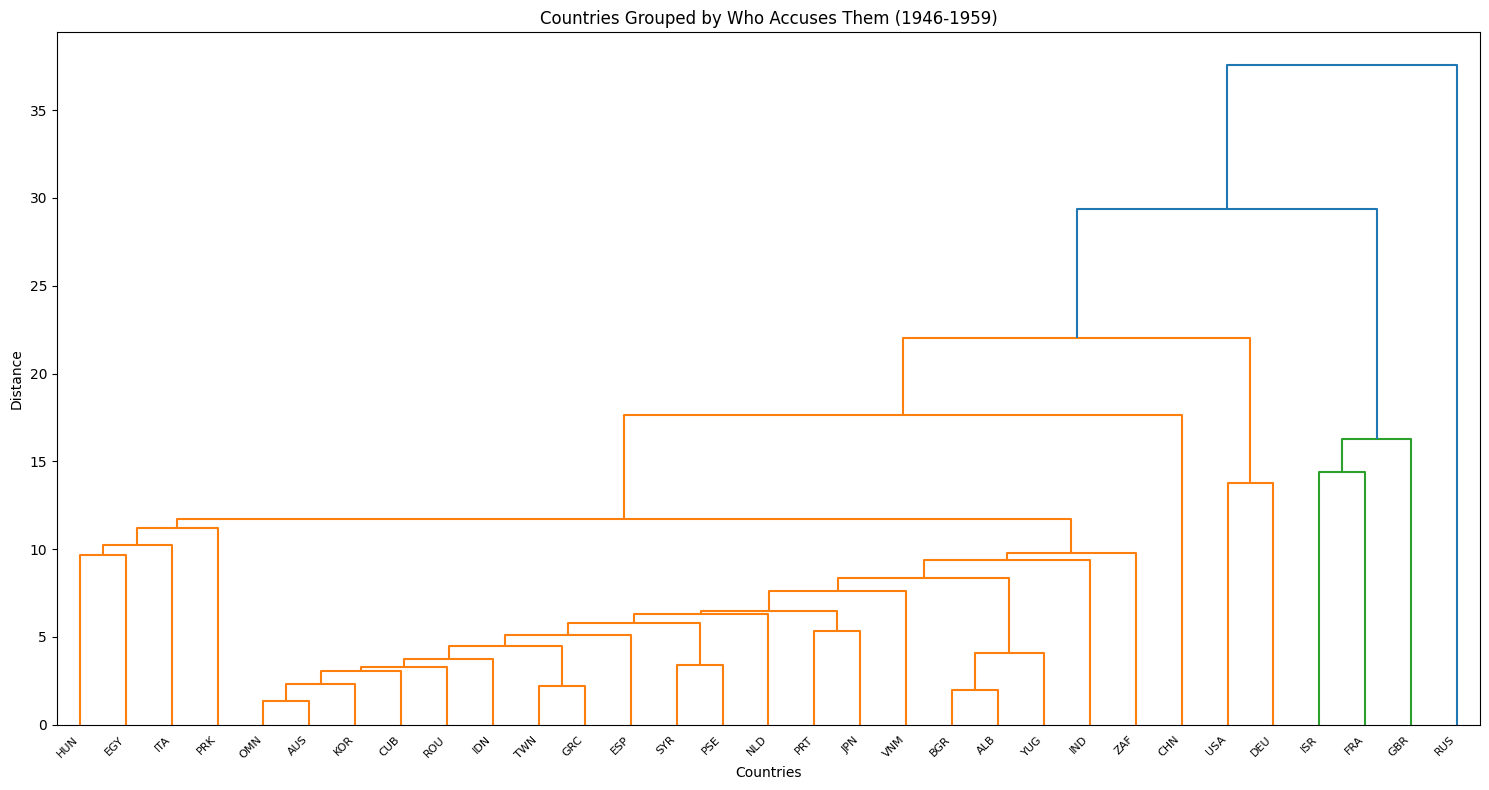


3 Clusters:
  Cluster 1: ['FRA', 'GBR', 'ISR']
  Cluster 2: ['ALB', 'AUS', 'BGR', 'CHN', 'CUB', 'DEU', 'EGY', 'ESP', 'GRC', 'HUN', 'IDN', 'IND', 'ITA', 'JPN', 'KOR', 'NLD', 'OMN', 'PRK', 'PRT', 'PSE', 'ROU', 'SYR', 'TWN', 'USA', 'VNM', 'YUG', 'ZAF']
  Cluster 3: ['RUS']

4 Clusters:
  Cluster 1: ['FRA', 'GBR', 'ISR']
  Cluster 2: ['DEU', 'USA']
  Cluster 3: ['ALB', 'AUS', 'BGR', 'CHN', 'CUB', 'EGY', 'ESP', 'GRC', 'HUN', 'IDN', 'IND', 'ITA', 'JPN', 'KOR', 'NLD', 'OMN', 'PRK', 'PRT', 'PSE', 'ROU', 'SYR', 'TWN', 'VNM', 'YUG', 'ZAF']
  Cluster 4: ['RUS']

5 Clusters:
  Cluster 1: ['FRA', 'GBR', 'ISR']
  Cluster 2: ['DEU', 'USA']
  Cluster 3: ['ALB', 'AUS', 'BGR', 'CUB', 'EGY', 'ESP', 'GRC', 'HUN', 'IDN', 'IND', 'ITA', 'JPN', 'KOR', 'NLD', 'OMN', 'PRK', 'PRT', 'PSE', 'ROU', 'SYR', 'TWN', 'VNM', 'YUG', 'ZAF']
  Cluster 4: ['CHN']
  Cluster 5: ['RUS']


In [40]:
# Filter for early period (1946-1959)
early_period = graph[(graph['year'] >= 1946) & (graph['year'] <= 1959)]

# Create accusation matrix: rows = target countries, columns = source countries
accusation_matrix = early_period.pivot_table(
    index='target',
    columns='source', 
    values='year',
    aggfunc='count',
    fill_value=0
)

print(f"Accusation matrix shape: {accusation_matrix.shape}")
print(f"Target countries: {len(accusation_matrix)}")
print(f"Source countries: {len(accusation_matrix.columns)}")

# Only include targets that are accused at least 3 times (lower threshold for early period)
min_accusations = 3
frequently_accused = accusation_matrix[accusation_matrix.sum(axis=1) >= min_accusations]
print(f"Frequently accused targets (>={min_accusations} accusations): {len(frequently_accused)}")
print(f"Countries: {list(frequently_accused.index)}")

# Calculate similarity between countries based on who accuses them
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()
accusation_scaled = scaler.fit_transform(frequently_accused)

# Hierarchical clustering
linkage_matrix = linkage(accusation_scaled, method='ward')

# Create dendrogram
plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, 
           labels=frequently_accused.index.tolist(),
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Countries Grouped by Who Accuses Them (1946-1959)')
plt.xlabel('Countries')
plt.ylabel('Distance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Get clusters at different levels
from scipy.cluster.hierarchy import fcluster

for n_clusters in [3, 4, 5]:
    clusters = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
    print(f"\n{n_clusters} Clusters:")
    for i in range(1, n_clusters + 1):
        cluster_countries = frequently_accused.index[clusters == i].tolist()
        if len(cluster_countries) > 0:
            print(f"  Cluster {i}: {cluster_countries}")

In [41]:
# Analyze who accuses each cluster in the 4-cluster solution
clusters_4 = fcluster(linkage_matrix, 4, criterion='maxclust')

cluster_assignments = {
    1: frequently_accused.index[clusters_4 == 1].tolist(),  # FRA, GBR, ISR
    2: frequently_accused.index[clusters_4 == 2].tolist(),  # DEU, USA  
    3: frequently_accused.index[clusters_4 == 3].tolist(),  # Large mixed cluster
    4: frequently_accused.index[clusters_4 == 4].tolist()   # RUS
}

print("Who accuses each cluster (1946-1959):")
for cluster_id, countries in cluster_assignments.items():
    if len(countries) > 0:
        print(f"\nCluster {cluster_id} ({', '.join(countries)}):")
        
        # Get all accusations against this cluster
        cluster_data = frequently_accused.loc[countries]
        
        # Average accusations from each source
        average_accusers = cluster_data.mean(axis=0).sort_values(ascending=False)
        
        print("Typically accused by:")
        for accuser, avg in average_accusers.head(10).items():
            if avg > 0.1:  # Only show meaningful accusers
                print(f"  {accuser}: {avg:.1f} avg accusations")

# Also calculate what percentage of total accusations each cluster represents
print(f"\nCluster sizes (percentage of total accusations in 1946-1959):")
total_early_accusations = len(early_period)

for cluster_id, countries in cluster_assignments.items():
    cluster_accusations = early_period[early_period['target'].isin(countries)]
    cluster_size = len(cluster_accusations)
    percentage = cluster_size / total_early_accusations * 100
    print(f"Cluster {cluster_id}: {cluster_size} accusations ({percentage:.1f}%)")

Who accuses each cluster (1946-1959):

Cluster 1 (FRA, GBR, ISR):
Typically accused by:
  EGY: 6.0 avg accusations
  IRQ: 5.7 avg accusations
  SYR: 5.0 avg accusations
  YEM: 4.7 avg accusations
  RUS: 4.3 avg accusations
  BLR: 4.0 avg accusations
  UKR: 3.3 avg accusations
  CSK: 2.7 avg accusations
  LBN: 2.3 avg accusations
  ALB: 2.3 avg accusations

Cluster 2 (DEU, USA):
Typically accused by:
  BLR: 9.0 avg accusations
  POL: 9.0 avg accusations
  UKR: 9.0 avg accusations
  CSK: 7.5 avg accusations
  RUS: 6.5 avg accusations
  HUN: 3.0 avg accusations
  YUG: 2.5 avg accusations
  BOL: 2.0 avg accusations
  GBR: 1.5 avg accusations
  FRA: 1.5 avg accusations

Cluster 3 (ALB, AUS, BGR, CHN, CUB, EGY, ESP, GRC, HUN, IDN, IND, ITA, JPN, KOR, NLD, OMN, PRK, PRT, PSE, ROU, SYR, TWN, VNM, YUG, ZAF):
Typically accused by:
  YUG: 0.8 avg accusations
  IND: 0.7 avg accusations
  GBR: 0.6 avg accusations
  UKR: 0.5 avg accusations
  BLR: 0.5 avg accusations
  POL: 0.5 avg accusations
  USA

Total accusations in 1946-1949: 165
Accusation matrix shape: (31, 31)
Target countries: 31
Source countries: 31
Frequently accused targets (>=2 accusations): 17
Countries: ['ALB', 'BGR', 'DEU', 'ESP', 'FRA', 'GBR', 'GRC', 'IND', 'ISR', 'ITA', 'JPN', 'NLD', 'RUS', 'TUR', 'USA', 'YUG', 'ZAF']


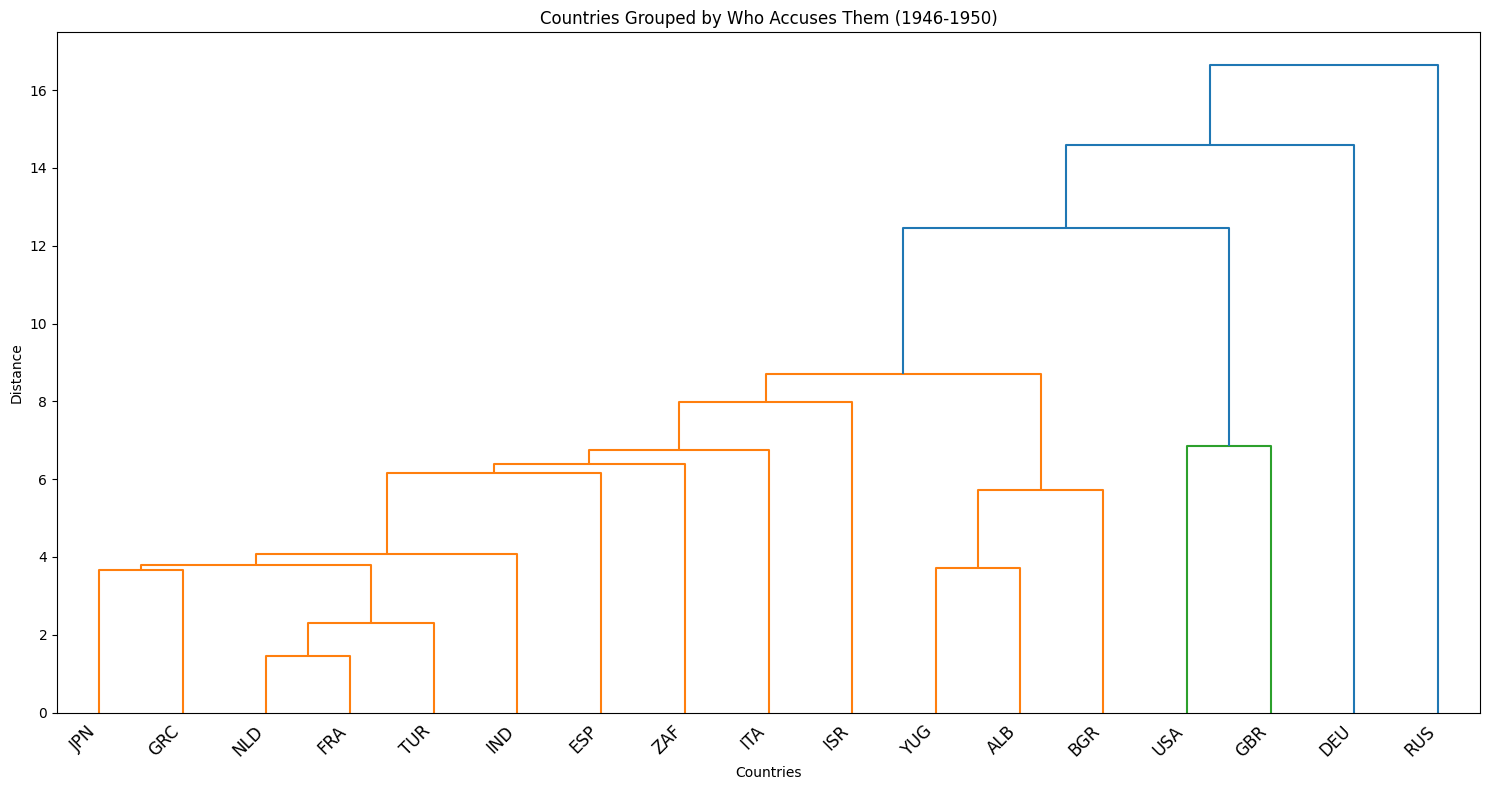


3 Clusters:
  Cluster 1: ['ALB', 'BGR', 'ESP', 'FRA', 'GBR', 'GRC', 'IND', 'ISR', 'ITA', 'JPN', 'NLD', 'TUR', 'USA', 'YUG', 'ZAF']
  Cluster 2: ['DEU']
  Cluster 3: ['RUS']

4 Clusters:
  Cluster 1: ['GBR', 'USA']
  Cluster 2: ['ALB', 'BGR', 'ESP', 'FRA', 'GRC', 'IND', 'ISR', 'ITA', 'JPN', 'NLD', 'TUR', 'YUG', 'ZAF']
  Cluster 3: ['DEU']
  Cluster 4: ['RUS']

5 Clusters:
  Cluster 1: ['GBR', 'USA']
  Cluster 2: ['ALB', 'BGR', 'YUG']
  Cluster 3: ['ESP', 'FRA', 'GRC', 'IND', 'ISR', 'ITA', 'JPN', 'NLD', 'TUR', 'ZAF']
  Cluster 4: ['DEU']
  Cluster 5: ['RUS']


In [43]:
# Filter for early post-war period (1946-1950)
postwar_period = graph[(graph['year'] >= 1946) & (graph['year'] < 1950)]

print(f"Total accusations in 1946-1949: {len(postwar_period)}")

# Create accusation matrix: rows = target countries, columns = source countries
accusation_matrix = postwar_period.pivot_table(
   index='target',
   columns='source', 
   values='year',
   aggfunc='count',
   fill_value=0
)

print(f"Accusation matrix shape: {accusation_matrix.shape}")
print(f"Target countries: {len(accusation_matrix)}")
print(f"Source countries: {len(accusation_matrix.columns)}")

# Only include targets that are accused at least 2 times (lower threshold for shorter period)
min_accusations = 2
frequently_accused = accusation_matrix[accusation_matrix.sum(axis=1) >= min_accusations]
print(f"Frequently accused targets (>={min_accusations} accusations): {len(frequently_accused)}")
print(f"Countries: {list(frequently_accused.index)}")

# Standardize and cluster
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

scaler = StandardScaler()
accusation_scaled = scaler.fit_transform(frequently_accused)

# Hierarchical clustering
linkage_matrix = linkage(accusation_scaled, method='ward')

# Create dendrogram
plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, 
          labels=frequently_accused.index.tolist(),
          orientation='top',
          distance_sort='descending',
          show_leaf_counts=True)
plt.title('Countries Grouped by Who Accuses Them (1946-1950)')
plt.xlabel('Countries')
plt.ylabel('Distance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Get clusters at different levels
for n_clusters in [3, 4, 5]:
   clusters = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
   print(f"\n{n_clusters} Clusters:")
   for i in range(1, n_clusters + 1):
       cluster_countries = frequently_accused.index[clusters == i].tolist()
       if len(cluster_countries) > 0:
           print(f"  Cluster {i}: {cluster_countries}")

In [44]:
# Calculate cluster percentages for 1946-1949
postwar_period = graph[(graph['year'] >= 1946) & (graph['year'] <= 1949)]
total_postwar_accusations = len(postwar_period)

# Use the 4-cluster solution
clusters_4 = fcluster(linkage_matrix, 4, criterion='maxclust')

cluster_assignments = {
   1: frequently_accused.index[clusters_4 == 1].tolist(),  # GBR, USA
   2: frequently_accused.index[clusters_4 == 2].tolist(),  # Large mixed cluster
   3: frequently_accused.index[clusters_4 == 3].tolist(),  # DEU
   4: frequently_accused.index[clusters_4 == 4].tolist()   # RUS
}

print(f"Cluster sizes (percentage of total accusations in 1946-1949):")
print(f"Total accusations: {total_postwar_accusations}")

for cluster_id, countries in cluster_assignments.items():
   if len(countries) > 0:
       cluster_accusations = postwar_period[postwar_period['target'].isin(countries)]
       cluster_size = len(cluster_accusations)
       percentage = cluster_size / total_postwar_accusations * 100
       print(f"Cluster {cluster_id} ({', '.join(countries)}): {cluster_size} accusations ({percentage:.1f}%)")

# Also show 3-cluster and 5-cluster solutions
print(f"\n3-cluster solution:")
clusters_3 = fcluster(linkage_matrix, 3, criterion='maxclust')
for i in range(1, 4):
   countries = frequently_accused.index[clusters_3 == i].tolist()
   if len(countries) > 0:
       cluster_accusations = postwar_period[postwar_period['target'].isin(countries)]
       cluster_size = len(cluster_accusations)
       percentage = cluster_size / total_postwar_accusations * 100
       print(f"  Cluster {i}: {cluster_size} accusations ({percentage:.1f}%)")

print(f"\n5-cluster solution:")
clusters_5 = fcluster(linkage_matrix, 5, criterion='maxclust')
for i in range(1, 6):
   countries = frequently_accused.index[clusters_5 == i].tolist()
   if len(countries) > 0:
       cluster_accusations = postwar_period[postwar_period['target'].isin(countries)]
       cluster_size = len(cluster_accusations)
       percentage = cluster_size / total_postwar_accusations * 100
       print(f"  Cluster {i}: {cluster_size} accusations ({percentage:.1f}%)")

Cluster sizes (percentage of total accusations in 1946-1949):
Total accusations: 165
Cluster 1 (GBR, USA): 37 accusations (22.4%)
Cluster 2 (ALB, BGR, ESP, FRA, GRC, IND, ISR, ITA, JPN, NLD, TUR, YUG, ZAF): 67 accusations (40.6%)
Cluster 3 (DEU): 21 accusations (12.7%)
Cluster 4 (RUS): 26 accusations (15.8%)

3-cluster solution:
  Cluster 1: 104 accusations (63.0%)
  Cluster 2: 21 accusations (12.7%)
  Cluster 3: 26 accusations (15.8%)

5-cluster solution:
  Cluster 1: 37 accusations (22.4%)
  Cluster 2: 20 accusations (12.1%)
  Cluster 3: 47 accusations (28.5%)
  Cluster 4: 21 accusations (12.7%)
  Cluster 5: 26 accusations (15.8%)


In [45]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

def analyze_single_year(year, min_accusations=2):
    """
    Analyze accusation patterns for a single year
    """
    year_data = graph[graph['year'] == year]
    
    if len(year_data) < 5:  # Need minimum data
        return None
    
    # 1. Absolute frequency
    target_counts = year_data['target'].value_counts()
    
    # 2. Co-referencing patterns
    accusation_matrix = year_data.pivot_table(
        index='target',
        columns='source', 
        values='year',
        aggfunc='count',
        fill_value=0
    )
    
    # Filter for minimum accusations
    frequently_accused = accusation_matrix[accusation_matrix.sum(axis=1) >= min_accusations]
    
    if len(frequently_accused) < 3:
        return None
    
    # Clustering analysis
    scaler = StandardScaler()
    try:
        accusation_scaled = scaler.fit_transform(frequently_accused)
        linkage_matrix = linkage(accusation_scaled, method='ward')
        
        # Try different cluster numbers
        cluster_results = {}
        for n_clusters in range(2, min(6, len(frequently_accused))):
            clusters = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
            
            # Calculate cluster sizes
            cluster_info = {}
            for i in range(1, n_clusters + 1):
                cluster_countries = frequently_accused.index[clusters == i].tolist()
                if len(cluster_countries) > 0:
                    cluster_accusations = year_data[year_data['target'].isin(cluster_countries)]
                    cluster_size = len(cluster_accusations)
                    percentage = cluster_size / len(year_data) * 100
                    cluster_info[i] = {
                        'countries': cluster_countries,
                        'size': cluster_size,
                        'percentage': percentage
                    }
            cluster_results[n_clusters] = cluster_info
        
    except:
        cluster_results = {}
    
    # 3. Structural shape metrics
    total_accusations = len(year_data)
    
    # Concentration metrics
    top_5_countries = target_counts.head(5).index.tolist()
    top_5_accusations = year_data[year_data['target'].isin(top_5_countries)]
    top_5_percentage = len(top_5_accusations) / total_accusations * 100
    
    # Gini coefficient for inequality
    counts = target_counts.values
    gini = np.sum(np.abs(counts[:, None] - counts[None, :])) / (2 * len(counts) * np.sum(counts))
    
    # Determine structure type (for best cluster solution)
    structure_type = "UNCLEAR"
    best_clustering = None
    
    if cluster_results:
        # Use 3-cluster solution if available
        if 3 in cluster_results:
            percentages = [c['percentage'] for c in cluster_results[3].values()]
            max_percentage = max(percentages) if percentages else 0
            second_max = sorted(percentages, reverse=True)[1] if len(percentages) > 1 else 0
            
            if max_percentage > 60:
                structure_type = "HEGEMONIC"
            elif max_percentage > 40 and second_max > 20:
                structure_type = "BIPOLAR"
            elif max_percentage < 40:
                structure_type = "MULTIPOLAR"
            else:
                structure_type = "DOMINANT"
            
            best_clustering = cluster_results[3]
    
    return {
        'year': year,
        'total_accusations': total_accusations,
        'unique_targets': len(target_counts),
        'top_5_percentage': top_5_percentage,
        'top_5_countries': top_5_countries,
        'gini_coefficient': gini,
        'structure_type': structure_type,
        'clustering': best_clustering,
        'all_clusters': cluster_results
    }

# Analyze year by year from 1946 onwards
print("Year-by-year structural analysis:")
print("Year | Total | Targets | Top5% | Gini | Structure | Dominant Cluster")
print("-" * 80)

yearly_results = {}
for year in range(1946, 1981):  # Start with 1946-1980
    result = analyze_single_year(year)
    if result:
        yearly_results[year] = result
        
        # Get dominant cluster info
        dominant_cluster = ""
        if result['clustering']:
            max_cluster = max(result['clustering'].items(), key=lambda x: x[1]['percentage'])
            dominant_cluster = f"{max_cluster[1]['percentage']:.1f}% ({len(max_cluster[1]['countries'])} countries)"
        
        print(f"{year} | {result['total_accusations']:5d} | {result['unique_targets']:7d} | {result['top_5_percentage']:5.1f} | {result['gini_coefficient']:.2f} | {result['structure_type']:10s} | {dominant_cluster}")

# Calculate year-over-year changes
print(f"\nYear-over-year change analysis:")
print("Year | ΔTotal | ΔTop5% | ΔGini | Structure Change")
print("-" * 60)

prev_result = None
for year, result in yearly_results.items():
    if prev_result:
        delta_total = result['total_accusations'] - prev_result['total_accusations']
        delta_top5 = result['top_5_percentage'] - prev_result['top_5_percentage']
        delta_gini = result['gini_coefficient'] - prev_result['gini_coefficient']
        structure_change = "CHANGE" if result['structure_type'] != prev_result['structure_type'] else ""
        
        print(f"{year} | {delta_total:+6d} | {delta_top5:+6.1f} | {delta_gini:+5.2f} | {structure_change}")
    
    prev_result = result

Year-by-year structural analysis:
Year | Total | Targets | Top5% | Gini | Structure | Dominant Cluster
--------------------------------------------------------------------------------
1946 |    31 |      13 |  61.3 | 0.29 | HEGEMONIC  | 64.5% (7 countries)
1947 |    41 |      14 |  61.0 | 0.35 | HEGEMONIC  | 61.0% (8 countries)
1948 |    42 |      16 |  69.0 | 0.46 | MULTIPOLAR | 28.6% (4 countries)
1949 |    51 |      24 |  49.0 | 0.38 | DOMINANT   | 51.0% (8 countries)
1950 |    55 |      16 |  74.5 | 0.54 | MULTIPOLAR | 32.7% (6 countries)
1951 |    55 |      18 |  69.1 | 0.49 | BIPOLAR    | 41.8% (4 countries)
1952 |    53 |      19 |  52.8 | 0.40 | DOMINANT   | 45.3% (6 countries)
1953 |    58 |      13 |  67.2 | 0.41 | MULTIPOLAR | 36.2% (4 countries)
1954 |    50 |      18 |  64.0 | 0.46 | DOMINANT   | 42.0% (6 countries)
1955 |    24 |      10 |  75.0 | 0.35 | BIPOLAR    | 41.7% (4 countries)
1956 |   139 |      20 |  75.5 | 0.61 | BIPOLAR    | 48.9% (3 countries)
1957 |    91 

In [46]:
# Analyze year by year for the full dataset
print("Year-by-year structural analysis (full dataset):")
print("Year | Total | Targets | Top5% | Gini | Structure | Dominant Cluster")
print("-" * 80)

yearly_results = {}
years = sorted(graph['year'].unique())

for year in years:
   result = analyze_single_year(year)
   if result:
       yearly_results[year] = result
       
       # Get dominant cluster info
       dominant_cluster = ""
       if result['clustering']:
           max_cluster = max(result['clustering'].items(), key=lambda x: x[1]['percentage'])
           dominant_cluster = f"{max_cluster[1]['percentage']:.1f}% ({len(max_cluster[1]['countries'])} countries)"
       
       print(f"{year} | {result['total_accusations']:5d} | {result['unique_targets']:7d} | {result['top_5_percentage']:5.1f} | {result['gini_coefficient']:.2f} | {result['structure_type']:10s} | {dominant_cluster}")

# Calculate year-over-year changes
print(f"\nYear-over-year change analysis:")
print("Year | ΔTotal | ΔTop5% | ΔGini | Structure Change")
print("-" * 60)

prev_result = None
for year in sorted(yearly_results.keys()):
   result = yearly_results[year]
   if prev_result:
       delta_total = result['total_accusations'] - prev_result['total_accusations']
       delta_top5 = result['top_5_percentage'] - prev_result['top_5_percentage']
       delta_gini = result['gini_coefficient'] - prev_result['gini_coefficient']
       structure_change = "CHANGE" if result['structure_type'] != prev_result['structure_type'] else ""
       
       print(f"{year} | {delta_total:+6d} | {delta_top5:+6.1f} | {delta_gini:+5.2f} | {structure_change}")
   
   prev_result = result

# Identify major structural transition years
print(f"\nMajor structural transitions:")
major_changes = []
prev_year = None
prev_structure = None

for year in sorted(yearly_results.keys()):
   result = yearly_results[year]
   if prev_structure and result['structure_type'] != prev_structure:
       major_changes.append((prev_year, year, prev_structure, result['structure_type']))
   prev_year = year
   prev_structure = result['structure_type']

for prev_year, curr_year, prev_struct, curr_struct in major_changes:
   print(f"{prev_year} → {curr_year}: {prev_struct} → {curr_struct}")

Year-by-year structural analysis (full dataset):
Year | Total | Targets | Top5% | Gini | Structure | Dominant Cluster
--------------------------------------------------------------------------------
1946 |    31 |      13 |  61.3 | 0.29 | HEGEMONIC  | 64.5% (7 countries)
1947 |    41 |      14 |  61.0 | 0.35 | HEGEMONIC  | 61.0% (8 countries)
1948 |    42 |      16 |  69.0 | 0.46 | MULTIPOLAR | 28.6% (4 countries)
1949 |    51 |      24 |  49.0 | 0.38 | DOMINANT   | 51.0% (8 countries)
1950 |    55 |      16 |  74.5 | 0.54 | MULTIPOLAR | 32.7% (6 countries)
1951 |    55 |      18 |  69.1 | 0.49 | BIPOLAR    | 41.8% (4 countries)
1952 |    53 |      19 |  52.8 | 0.40 | DOMINANT   | 45.3% (6 countries)
1953 |    58 |      13 |  67.2 | 0.41 | MULTIPOLAR | 36.2% (4 countries)
1954 |    50 |      18 |  64.0 | 0.46 | DOMINANT   | 42.0% (6 countries)
1955 |    24 |      10 |  75.0 | 0.35 | BIPOLAR    | 41.7% (4 countries)
1956 |   139 |      20 |  75.5 | 0.61 | BIPOLAR    | 48.9% (3 countries

In [47]:
def analyze_single_year_detailed(year, min_accusations=2):
    """
    Analyze accusation patterns for a single year with detailed cluster info
    """
    year_data = graph[graph['year'] == year]
    
    if len(year_data) < 5:
        return None
    
    # Basic metrics
    target_counts = year_data['target'].value_counts()
    
    # Clustering analysis
    accusation_matrix = year_data.pivot_table(
        index='target',
        columns='source', 
        values='year',
        aggfunc='count',
        fill_value=0
    )
    
    frequently_accused = accusation_matrix[accusation_matrix.sum(axis=1) >= min_accusations]
    
    if len(frequently_accused) < 3:
        return None
    
    # Clustering
    scaler = StandardScaler()
    try:
        accusation_scaled = scaler.fit_transform(frequently_accused)
        linkage_matrix = linkage(accusation_scaled, method='ward')
        clusters = fcluster(linkage_matrix, 3, criterion='maxclust')  # Use 3 clusters
        
        # Calculate cluster info
        significant_clusters = []
        for i in range(1, 4):
            cluster_countries = frequently_accused.index[clusters == i].tolist()
            if len(cluster_countries) > 0:
                cluster_accusations = year_data[year_data['target'].isin(cluster_countries)]
                cluster_size = len(cluster_accusations)
                percentage = cluster_size / len(year_data) * 100
                
                # Only include if significant (>10% or single country >5%)
                if percentage > 10 or (len(cluster_countries) == 1 and percentage > 5):
                    significant_clusters.append({
                        'countries': cluster_countries,
                        'percentage': percentage,
                        'size': cluster_size
                    })
        
        # Sort by percentage
        significant_clusters.sort(key=lambda x: x['percentage'], reverse=True)
        
    except:
        significant_clusters = []
    
    # Basic metrics
    total_accusations = len(year_data)
    top_5_countries = target_counts.head(5).index.tolist()
    top_5_accusations = year_data[year_data['target'].isin(top_5_countries)]
    top_5_percentage = len(top_5_accusations) / total_accusations * 100
    
    # Gini coefficient
    counts = target_counts.values
    gini = np.sum(np.abs(counts[:, None] - counts[None, :])) / (2 * len(counts) * np.sum(counts))
    
    return {
        'year': year,
        'total_accusations': total_accusations,
        'unique_targets': len(target_counts),
        'top_5_percentage': top_5_percentage,
        'gini_coefficient': gini,
        'significant_clusters': significant_clusters
    }

# Analyze with detailed cluster information
print("Year-by-year analysis with significant clusters:")
print("=" * 100)

yearly_results_detailed = {}
years = sorted(graph['year'].unique())

for year in years:
    result = analyze_single_year_detailed(year)
    if result:
        yearly_results_detailed[year] = result
        
        print(f"\n{year}: {result['total_accusations']} total accusations | {result['unique_targets']} targets | Top5: {result['top_5_percentage']:.1f}% | Gini: {result['gini_coefficient']:.2f}")
        
        if result['significant_clusters']:
            for i, cluster in enumerate(result['significant_clusters']):
                countries_str = ', '.join(cluster['countries'])
                if len(countries_str) > 60:
                    countries_str = countries_str[:60] + "..."
                print(f"  Cluster {i+1}: {cluster['percentage']:.1f}% ({cluster['size']} accusations) - {countries_str}")
        else:
            print("  No significant clusters")

# Summary of major cluster patterns
print(f"\n" + "="*100)
print("SUMMARY: Years with major cluster patterns (>50% in single cluster):")
major_cluster_years = []

for year, result in yearly_results_detailed.items():
    if result['significant_clusters']:
        top_cluster = result['significant_clusters'][0]
        if top_cluster['percentage'] > 50:
            major_cluster_years.append((year, top_cluster))

for year, cluster in major_cluster_years:
    countries_str = ', '.join(cluster['countries'])
    print(f"{year}: {cluster['percentage']:.1f}% - {countries_str}")

Year-by-year analysis with significant clusters:

1946: 31 total accusations | 13 targets | Top5: 61.3% | Gini: 0.29
  Cluster 1: 64.5% (20 accusations) - DEU, GBR, GRC, ITA, JPN, USA, ZAF
  Cluster 2: 12.9% (4 accusations) - RUS
  Cluster 3: 9.7% (3 accusations) - ESP

1947: 41 total accusations | 14 targets | Top5: 61.0% | Gini: 0.35
  Cluster 1: 61.0% (25 accusations) - ALB, BGR, GBR, GRC, ITA, NLD, USA, YUG
  Cluster 2: 19.5% (8 accusations) - DEU
  Cluster 3: 9.8% (4 accusations) - RUS

1948: 42 total accusations | 16 targets | Top5: 69.0% | Gini: 0.46
  Cluster 1: 28.6% (12 accusations) - DEU, ISR, ITA, JPN
  Cluster 2: 26.2% (11 accusations) - GBR, USA
  Cluster 3: 23.8% (10 accusations) - RUS

1949: 51 total accusations | 24 targets | Top5: 49.0% | Gini: 0.38
  Cluster 1: 51.0% (26 accusations) - ALB, BGR, DEU, GBR, JPN, USA, YUG, ZAF
  Cluster 2: 15.7% (8 accusations) - RUS
  Cluster 3: 5.9% (3 accusations) - ISR

1950: 55 total accusations | 16 targets | Top5: 74.5% | Gini: 0